# STEP 0: Import Libraries

In [1]:
import pandapower as pp
import pandapower.networks as ppnet
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt


import pandapower.networks
import pandapower.contingency
import pandapower.control
import pandapower.timeseries
import pandapower.plotting

In [2]:
# we need to import also copy in order to create a copy of the network to do the contingency analysis
import copy

# STEP 1

### Step 1.1: What is the state of the CIGRE MV benchmark network? Check bus voltage [pu] and line/transformer loading [%].

### Importing network

In [3]:
from pandapower.networks import create_cigre_network_mv

net = ppnet.create_cigre_network_mv(with_der=False)

### Reduce the load in the existing network by half using the code below and continue using the network for further analysis

In [4]:
# Reduce all Loads by half
net.load['p_mw'] = net.load['p_mw'] / 2
net.load['q_mvar'] = net.load[ 'q_mvar'] / 2

pp.runpp(net)


Check network properties 

In [5]:
net #gives net info

This pandapower network includes the following parameter tables:
   - bus (15 elements)
   - load (18 elements)
   - switch (8 elements)
   - ext_grid (1 element)
   - line (15 elements)
   - trafo (2 elements)
 and the following results tables:
   - res_bus (15 elements)
   - res_line (15 elements)
   - res_trafo (2 elements)
   - res_ext_grid (1 element)
   - res_load (18 elements)
   - res_switch (8 elements)

In [6]:
# create a copy of the network to use it as a baseline 
net_base = copy.deepcopy(net)

In [7]:
net.res_load

,p_mw,q_mvar
0,7.497000,1.522331
1,0.138225,0.034642
2,0.215825,0.054091
3,0.363750,0.091164
4,0.274025,0.068677
5,0.293425,0.073539
6,0.237650,0.059561
7,0.164900,0.041328
8,7.497000,1.522331
9,0.104275,0.026134


In [8]:
net.res_bus 

,vm_pu,va_degree,p_mw,q_mvar
0,1.030000,0.000000,-22.438062,-6.540274
1,1.014288,-33.184545,9.919500,2.318568
2,1.003992,-33.706337,0.000000,0.000000
3,0.987476,-34.524225,0.250850,0.104441
4,0.986631,-34.571620,0.215825,0.054091
5,0.986053,-34.604239,0.363750,0.091164
6,0.985376,-34.643090,0.274025,0.068677
7,0.984867,-34.643976,0.038250,0.023705
8,0.984974,-34.638250,0.293425,0.073539
9,0.984523,-34.656398,0.286875,0.177789


All the voltages are inside the range 0.9 p.u. - 1.1 p.u.

In [9]:
net.res_line

,p_from_mw,q_from_mvar,p_to_mw,q_to_mvar,pl_mw,ql_mvar,i_from_ka,i_to_ka,i_ka,vm_from_pu,va_from_degree,vm_to_pu,va_to_degree,loading_percent
0,2.209018e+00,0.503814,-2.191295e+00,-5.330427e-01,1.772280e-02,-0.029229,0.064485,6.484304e-02,0.064843,1.014288,-33.184545,1.003992,-33.706337,44.719335
1,2.191295e+00,0.533043,-2.163105e+00,-5.760137e-01,2.819000e-02,-0.042971,0.064843,6.543907e-02,0.065439,1.003992,-33.706337,0.987476,-34.524225,45.130392
2,8.546525e-01,0.160944,-8.540585e-01,-1.713850e-01,5.940587e-04,-0.010441,0.025424,2.548679e-02,0.025487,0.987476,-34.524225,0.986631,-34.571620,17.577096
3,6.382335e-01,0.117294,-6.379291e-01,-1.272090e-01,3.043127e-04,-0.009915,0.018987,1.904360e-02,0.019044,0.986631,-34.571620,0.986053,-34.604239,13.133517
4,2.741791e-01,0.036045,-2.740250e-01,-6.425018e-02,1.541433e-04,-0.028206,0.008096,8.245532e-03,0.008246,0.986053,-34.604239,0.985376,-34.643090,5.686574
5,-3.825000e-02,-0.023705,3.825330e-02,-7.065781e-03,3.304257e-06,-0.030771,0.001319,1.140089e-03,0.001319,0.984867,-34.643976,0.984974,-34.638250,0.909654
6,7.238830e-01,0.265258,-7.236368e-01,-2.708015e-01,2.461967e-04,-0.005543,0.022595,2.265503e-02,0.022655,0.984974,-34.638250,0.984523,-34.656398,15.624159
7,4.367618e-01,0.093012,-4.365620e-01,-1.068972e-01,1.997743e-04,-0.013885,0.013094,1.318633e-02,0.013186,0.984523,-34.656398,0.983955,-34.686293,9.094024
8,1.649120e-01,0.026265,-1.649000e-01,-3.231709e-02,1.197685e-05,-0.006052,0.004899,4.930342e-03,0.004930,0.983955,-34.686293,0.983868,-34.691341,3.400236
9,1.057603e+00,0.310629,-1.055561e+00,-3.317317e-01,2.041580e-03,-0.021103,0.032224,3.242805e-02,0.032428,0.987476,-34.524225,0.984974,-34.638250,22.364171


All loading percentages are below 45.13%, so no overloading risks for the lines

In [10]:
net.res_trafo

,p_hv_mw,q_hv_mvar,p_lv_mw,q_lv_mvar,pl_mw,ql_mvar,i_hv_ka,i_lv_ka,vm_hv_pu,va_hv_degree,vm_lv_pu,va_lv_degree,loading_percent
0,12.138165,3.545881,-12.128518,-2.822382,0.009647,0.723499,0.064438,0.354411,1.03,0.0,1.014288,-33.184545,49.108684
1,10.299897,2.994393,-10.292956,-2.473834,0.006941,0.520559,0.054659,0.300624,1.03,0.0,1.016531,-32.695956,41.655671


All transformer loading percentages are below 50%

In [11]:
net.res_switch

,i_ka,loading_percent,p_from_mw,q_from_mvar,p_to_mw,q_to_mvar
0,0.000130,NaN,NaN,NaN,NaN,NaN
1,0.000000,NaN,NaN,NaN,NaN,NaN
2,0.000000,NaN,NaN,NaN,NaN,NaN
3,0.000264,NaN,NaN,NaN,NaN,NaN
4,0.000000,NaN,NaN,NaN,NaN,NaN
5,0.000074,NaN,NaN,NaN,NaN,NaN
6,0.064438,NaN,NaN,NaN,NaN,NaN
7,0.054659,NaN,NaN,NaN,NaN,NaN


## STEP 1.2 and 1.3: Contingency Analysis 

How to perform N-1 contingency analysis:  
a) Put one line out of service  
b) Operating the switches to provide supply to the customer/load  
c) Run a power flow  
d) Access the results  
e) There are buses/lines violating the power quality limits? If yes, the line you just put out of service is a critical line. If no, it is not.  
f) Put the line in service again  
g) Do this for all the 12 lines (do not consider Line 6-7, Line 11-4, Line 14-8. They are the switches).  

In [12]:
## Copying the network in order to operate the analysis on it
net_contanalysis1 = copy.deepcopy(net_base)
net_contanalysis1

This pandapower network includes the following parameter tables:
   - bus (15 elements)
   - load (18 elements)
   - switch (8 elements)
   - ext_grid (1 element)
   - line (15 elements)
   - trafo (2 elements)
 and the following results tables:
   - res_bus (15 elements)
   - res_line (15 elements)
   - res_trafo (2 elements)
   - res_ext_grid (1 element)
   - res_load (18 elements)
   - res_switch (8 elements)

Create a function so that the contingency analysis would be easy to call later:

In [13]:
def cont_analysis(net, v_min, v_max, line_loading_limit, trafo_loading_limit):
    net.switch.loc[:, "closed"] = True
    excluded_lines = [12, 13, 14]
    records = []

    for line_idx in net.line.index:
        if line_idx in excluded_lines:
            continue

        net.line.at[line_idx, 'in_service'] = False

        try:
            pp.runpp(net)
            bus_voltages = net.res_bus.vm_pu
            voltage_violation = ((bus_voltages < v_min) | (bus_voltages > v_max)).any()

            line_loading = net.res_line.loading_percent
            line_loading_violation = (line_loading > line_loading_limit).any()

            # Exclude outaged line loading
            other_lines_loading = line_loading.drop(line_idx)
            max_other_line_loading = other_lines_loading.max() if len(other_lines_loading) > 0 else 0

            # Get line index of max loading
            if len(other_lines_loading) > 0:
                max_line_idx = other_lines_loading.idxmax()
                max_line_name = net.line.at[max_line_idx, 'name'] if 'name' in net.line.columns else str(max_line_idx)
            else:
                max_line_idx = None
                max_line_name = "N/A"

            trafo_loading = net.res_trafo.loading_percent
            trafo_loading_violation = (trafo_loading > trafo_loading_limit).any()

            critical = voltage_violation or line_loading_violation or trafo_loading_violation

            if critical:
                from_bus = net.line.at[line_idx, 'from_bus']
                to_bus = net.line.at[line_idx, 'to_bus']
                max_trafo_loading = trafo_loading.max() if len(trafo_loading) > 0 else None
                line_name = net.line.at[line_idx, 'name'] if 'name' in net.line.columns else str(line_idx)

                print(f"Critical contingency found when removing '{line_name}':")
                print(f" - Max loading on other lines: '{max_line_name}' at {max_other_line_loading:.1f} %")
                print(f" - Voltages: Bus {from_bus} = {bus_voltages[from_bus]:.3f} pu, Bus {to_bus} = {bus_voltages[to_bus]:.3f} pu")
                print(f" - Max Transformer loading: {max_trafo_loading:.1f} %")

                records.append({
                    'outaged_line_index': line_idx,
                    'from_bus_voltage': bus_voltages[from_bus],
                    'to_bus_voltage': bus_voltages[to_bus],
                    'max_other_line_loading': max_other_line_loading,
                    'max_other_line_name': max_line_name,
                    'transformer_loading_max': max_trafo_loading,
                    'critical_line': critical,
                    'outaged_line_name': line_name
                })

        except Exception:
            pass

        net.line.at[line_idx, 'in_service'] = True

    if len(records) == 0:
        print("No contingencies found")

    return pd.DataFrame(records), None


Now performing the contingency analysis

In [14]:
cont_analysis(net_contanalysis1, v_min=0.9, v_max=1.1, line_loading_limit=100, trafo_loading_limit=100)

No contingencies found


(Empty DataFrame
 Columns: []
 Index: [],
 None)

As we can see from the previous results, no contingencies were identified

# STEP 2

## Step 2.1

Network with time -varying loads:  
• 2.1 Where should the four freight depots be connected to the network based on the baseline network  
analysis from Step 1?  
•Analyze network capacity at different buses based on Step 1 results.  
•Consider depot requirements and select optimal connection points:  
-ICA Depot: Grocery distribution    
-PostNord Depot:Package delivery  
-Mathem Depot:Food retail distribution  
-Airmee Depot:Package delivery (small scale)  
•Justify connection point selection based on baseline network capacity and contingency performance.  

Extract maximum values from the Excel datasheet for each depot to run the steady state analysis

In [15]:
# Excel file in the same folder as this script
Freights_loads = "Load_profiles_Freight transports.xlsx"

# Read first sheet
df_depots = pd.read_excel(Freights_loads)

# Coerce everything to numeric (non-numeric -> NaN)
num = df_depots.apply(pd.to_numeric, errors="coerce")

# Auto-pick depot columns:
# - keep columns that have at least one numeric value
# - drop obvious timestamp columns by name (date/time)
candidate_cols = [
    c for c in df_depots.columns
    if num[c].notna().any() and ("date" not in str(c).lower()) and ("time" not in str(c).lower())
]

# Define time column name (adjust if your column is named differently)
time_col = "Time" if "Time" in df_depots.columns else None

# Use candidate_cols for depot columns
depot_cols = candidate_cols.copy()
# Build hourly_loads DataFrame in MW
hourly_loads = df_depots[[time_col] + depot_cols].copy()
for col in depot_cols:
    hourly_loads[col] = pd.to_numeric(hourly_loads[col], errors='coerce') / 1000  # convert kW to MW

# Now hourly_loads is ready for use!
print(hourly_loads.head())



# Take column-wise maximum in kW and convert to MW
max_mw = (num[candidate_cols].max() / 1000).rename("Max_MW")

# Show results
print("Max load per depot (MW):")
print(max_mw.to_frame())

# Name the variables for the analysis and put them in a dictionary
max_mw_ICA = max_mw["ICA"]
max_mw_Mathem = max_mw["Mathem"]
max_mw_Postnord = max_mw["Postnord"]
max_mw_Airmee = max_mw["Airmee"]

load_sizes={'ICA': max_mw_ICA, 'Mathem': max_mw_Mathem, 'Postnord': max_mw_Postnord, 'Airmee': max_mw_Airmee}
print(load_sizes)

             Time       ICA    Mathem  Postnord    Airmee
0  00:00:00+01:00  0.853470  0.558823  0.476323  0.179549
1  01:00:00+01:00  0.862975  0.521902  0.473712  0.161848
2  02:00:00+01:00  0.839105  0.549134  0.450265  0.174293
3  03:00:00+01:00  0.817137  0.521987  0.458649  0.149116
4  04:00:00+01:00  0.838922  0.516426  0.418630  0.148731
Max load per depot (MW):
            Max_MW
ICA       1.500614
Mathem    1.009949
Postnord  1.416677
Airmee    0.456397
{'ICA': np.float64(1.500614182), 'Mathem': np.float64(1.0099493720000001), 'Postnord': np.float64(1.416676579), 'Airmee': np.float64(0.4563970074)}


Find buses suitable for connecting new loads, excluding buses 0, 1, and 12

In [16]:
# Creating a copy of the baseline network to be used to add the loads
net_depotstobus = copy.deepcopy(net_base)

In [17]:
def find_suitable_buses(net, max_loading_threshold=85):

    # Define prohibited buses
    prohibited_buses = [0, 1, 12]
    
    # Get all available buses (excluding prohibited ones)
    all_buses = list(set(net.bus.index) - set(prohibited_buses)) 
      
    # Sort buses by voltage (highest first) for better candidates
    all_buses.sort(key=lambda x: net.res_bus.loc[x, 'vm_pu'], reverse=True)
    
    # Further filter by checking connected element loading
    final_candidates = []
    
    for bus in all_buses:
        bus_loading_ok = True
        
        # Check lines connected to this bus
        connected_lines = net.line[(net.line.from_bus == bus) | (net.line.to_bus == bus)]
        if not connected_lines.empty:
            max_line_loading = net.res_line.loc[connected_lines.index].loading_percent.max()
            if max_line_loading > max_loading_threshold:
                bus_loading_ok = False
                print(f"Bus {bus} excluded due to line loading: {max_line_loading:.1f}%")
                continue
        
        if bus_loading_ok:
            final_candidates.append(bus)
    
    return final_candidates

Create a function that adds the single load to a bus, assuming a power factor of 0.95

In [18]:
def add_single_load(net, load_name, load_size_mw, bus_id, power_factor=0.95):

    # Calculate reactive power
    q_mvar = load_size_mw * ((1 - power_factor**2)**0.5 / power_factor)
    
    # Add the load
    pp.create_load(net, bus=bus_id, p_mw=load_size_mw, q_mvar=q_mvar, name=load_name)
    
    print(f"Added {load_name} ({load_size_mw:.3f} MW) to bus {bus_id}")

Validate if adding a load to a specific bus would cause violations, returns True if acceptable, False if constraints violated

In [19]:
def validate_network_after_changes(net, vmin=0.90, vmax=1.10, loading_max=100.0, run_contingency=True):
    """
    Run base power flow checks and (optionally) N-1 contingency analysis.
    Returns True only if base checks AND contingency checks pass.
    """
    pp.runpp(net)

    # base checks
    voltage_violations = net.res_bus[(net.res_bus.vm_pu < vmin) | (net.res_bus.vm_pu > vmax)]
    line_overloads = net.res_line[net.res_line.loading_percent > loading_max]
    trafo_overloads = net.res_trafo[net.res_trafo.loading_percent > loading_max]

    print(f"\n=== VALIDATION RESULTS ===")
    print(f"Voltage violations: {len(voltage_violations)}")
    if len(voltage_violations) > 0:
        print(voltage_violations[['vm_pu']].round(3))

    print(f"Line overloads: {len(line_overloads)}")
    if len(line_overloads) > 0:
        print(line_overloads[['loading_percent']].round(1))

    print(f"Transformer overloads: {len(trafo_overloads)}")
    if len(trafo_overloads) > 0:
        print(trafo_overloads[['loading_percent']].round(1))

    # contingency check (silent)
    has_critical_lines = False
    if run_contingency:
        summary_df, _ = cont_analysis(net, vmin, vmax, line_loading_limit=loading_max, trafo_loading_limit=100)
        has_critical_lines = (len(summary_df) > 0) and summary_df['critical_line'].any()
        if has_critical_lines:
            crit_names = summary_df.loc[summary_df['critical_line'], 'outaged_line_name'].tolist()
            print("\nContingency analysis found critical lines: ", crit_names)

    return (len(voltage_violations) == 0 and
            len(line_overloads) == 0 and
            len(trafo_overloads) == 0 and
            (not has_critical_lines))

Execute the previous functions to add each load in the preferred bus candidates and validate the feasibility.

In [20]:
not_added_loads = {}
depot_bus_map = {}

# Loop through all loads and try to place them
for load_name, load_size in load_sizes.items():
    print(f"\n=== Trying to place load {load_name} ({load_size:.3f} MW) ===")
    
    # Get candidate buses
    candidates = find_suitable_buses(net_depotstobus)
    placed = False
    
    for bus in candidates:
        # Add the load
        add_single_load(net_depotstobus, load_name, load_size, bus)
        
        # Validate
        if validate_network_after_changes(net_depotstobus):
            print(f"Load {load_name} successfully placed at bus {bus}")
            placed = True
            depot_bus_map[load_name] = bus
            break
        else:
            # Remove the last added load if validation failed
            last_load_idx = net_depotstobus.load.index[-1]
            net_depotstobus.load.drop(last_load_idx, inplace=True)
            print(f"Load {load_name} at bus {bus} caused violations. Trying next bus...")
    
    if not placed:
        print(f"Could not place load {load_name} anywhere without violations.")
        not_added_loads[load_name] = load_size



=== Trying to place load ICA (1.501 MW) ===
Added ICA (1.501 MW) to bus 13

=== VALIDATION RESULTS ===
Voltage violations: 0
Line overloads: 0
Transformer overloads: 0
No contingencies found
Load ICA successfully placed at bus 13

=== Trying to place load Mathem (1.010 MW) ===
Added Mathem (1.010 MW) to bus 13

=== VALIDATION RESULTS ===
Voltage violations: 0
Line overloads: 0
Transformer overloads: 0
Critical contingency found when removing 'Line 12-13':
 - Max loading on other lines: 'Line 2-3' at 112.8 %
 - Voltages: Bus 12 = 1.017 pu, Bus 13 = 0.905 pu
 - Max Transformer loading: 62.9 %

Contingency analysis found critical lines:  ['Line 12-13']
Load Mathem at bus 13 caused violations. Trying next bus...
Added Mathem (1.010 MW) to bus 2

=== VALIDATION RESULTS ===
Voltage violations: 0
Line overloads: 0
Transformer overloads: 0
Critical contingency found when removing 'Line 12-13':
 - Max loading on other lines: 'Line 1-2' at 108.8 %
 - Voltages: Bus 12 = 1.017 pu, Bus 13 = 0.928 

Show final network summary


In [21]:
print("\n=== FINAL NETWORK SUMMARY ===")
print("Not added loads:")
for key, value in not_added_loads.items():
    print(f"{key}: {value}")
if not not_added_loads:
    print("All loads were correctly added to the network")
print(f"Total active power demand: {net_depotstobus.load.p_mw.sum():.3f} MW")
print(f"Total reactive power demand: {net_depotstobus.load.q_mvar.sum():.3f} Mvar")
print(f"Total number of loads: {len(net_depotstobus.load)}")
print(f"Minimum bus voltage: {net_depotstobus.res_bus.vm_pu.min():.3f} pu")
print(f"Maximum line loading: {net_depotstobus.res_line.loading_percent.max():.1f}%")


=== FINAL NETWORK SUMMARY ===
Not added loads:
Mathem: 1.0099493720000001
Postnord: 1.416676579
Total active power demand: 24.328 MW
Total reactive power demand: 6.163 Mvar
Total number of loads: 20
Minimum bus voltage: 0.979 pu
Maximum line loading: 51.3%


In [22]:
def validate_network_no_contingency(net):

    pp.runpp(net)
    
    # Check voltage limits (typical MV limits: 0.9 - 1.1 pu)
    voltage_violations = net.res_bus[(net.res_bus.vm_pu < 0.90) | (net.res_bus.vm_pu > 1.1)]
    
    # Check line loading
    line_overloads = net.res_line[net.res_line.loading_percent > 100]
    
    # Check transformer loading
    trafo_overloads = net.res_trafo[net.res_trafo.loading_percent > 100]
    
    print(f"\n=== VALIDATION RESULTS ===")
    print(f"Voltage violations: {len(voltage_violations)}")
    if len(voltage_violations) > 0:
        print(voltage_violations[['vm_pu']].round(3))
    
    print(f"Line overloads: {len(line_overloads)}")
    if len(line_overloads) > 0:
        print(line_overloads[['loading_percent']].round(1))
    
    print(f"Transformer overloads: {len(trafo_overloads)}")
    if len(trafo_overloads) > 0:
        print(trafo_overloads[['loading_percent']].round(1))
    
    return (len(voltage_violations) == 0 and
            len(line_overloads) == 0 and
            len(trafo_overloads) == 0)

Now adding the not added loads to the network without checking the contingency analysis. These loads are automatically added to the most suitable buses.

In [23]:
# Loop through all loads and try to place them
for load_name, load_size in not_added_loads.items():
    print(f"\n=== Trying to place load {load_name} ({load_size:.3f} MW) ===")
    
    # Get candidate buses
    candidates = find_suitable_buses(net_depotstobus)
    placed = False
    
    for bus in candidates:
        # Add the load
        add_single_load(net_depotstobus, load_name, load_size, bus)
        
        # Validate
        if validate_network_no_contingency(net_depotstobus):
            print(f"Load {load_name} successfully placed at bus {bus}")
            placed = True
            depot_bus_map[load_name] = bus
            break
        else:
            # Remove the last added load if validation failed
            last_load_idx = net_depotstobus.load.index[-1]
            net_depotstobus.load.drop(last_load_idx, inplace=True)
            print(f"Load {load_name} at bus {bus} caused violations. Trying next bus...")
    
    if not placed:
        print(f"Could not place load {load_name} anywhere without violations.")
        not_added_loads[load_name] = load_size


=== Trying to place load Mathem (1.010 MW) ===
Added Mathem (1.010 MW) to bus 2

=== VALIDATION RESULTS ===
Voltage violations: 0
Line overloads: 0
Transformer overloads: 0
Load Mathem successfully placed at bus 2

=== Trying to place load Postnord (1.417 MW) ===
Added Postnord (1.417 MW) to bus 2

=== VALIDATION RESULTS ===
Voltage violations: 0
Line overloads: 0
Transformer overloads: 0
Load Postnord successfully placed at bus 2


In [24]:
print(depot_bus_map)

{'ICA': 13, 'Airmee': 13, 'Mathem': 2, 'Postnord': 2}


## Step 2.2
- Import 2-week hourly load profiles for all four depots (ICA, PostNord, Mathem, Airmee).
- Connect depot load profiles at the buses identified in Step 2.1.
- Perform hourly load flow analysis for the complete 2-week period.
- Consider voltage limits: maximum 1.1 pu, minimum 0.9 pu.
- Document voltage variations and line loading changes compared to baseline network.

Importing libraries


In [25]:
import os
import numpy as np
import pandas as pd
import tempfile
import random
import pandapower as pp
from pandapower.timeseries import DFData
from pandapower.timeseries import OutputWriter
from pandapower.timeseries.run_time_series import run_timeseries
from pandapower.control import ConstControl


In [26]:
# check of the data frames (not necessary)
print("Available network:", isinstance(net, pp.pandapowerNet))
print("df_depots:", getattr(df_depots, "shape", None))

Available network: True
df_depots: (336, 6)


**Building the `profiles` DataFrame** :

* Create an index using 'Date' and 'Time' columns
* Select the load columns (e.g. *ICA*, *Mathem*, *Postnord*, *Airmee*), convert from kW to MW


In [27]:
df_depots.columns

Index(['Date', 'Time', 'ICA', 'Mathem', 'Postnord', 'Airmee'], dtype='object')

In [28]:
# 2) Merge Date+Time -> datetime, drop timezone
dt = pd.to_datetime(df_depots["Date"].astype(str) + " " + df_depots["Time"].astype(str), errors="coerce")
dt = dt.dt.tz_localize(None)


In [29]:
# We’re converting the chosen time column to a datetime index and setting it as the DataFrame’s index after 
# dropping the original column.
df = df_depots.copy()
df.index = dt
df = df.drop(columns=["Date", "Time"])


In [30]:
# Build profiles DataFrame directly (kW -> MW)
profiles = df[["ICA","Mathem","Postnord","Airmee"]] / 1000.0

In [31]:
profiles.head()

,ICA,Mathem,Postnord,Airmee
2026-01-01 00:00:00,0.853470,0.558823,0.476323,0.179549
2026-01-01 01:00:00,0.862975,0.521902,0.473712,0.161848
2026-01-01 02:00:00,0.839105,0.549134,0.450265,0.174293
2026-01-01 03:00:00,0.817137,0.521987,0.458649,0.149116
2026-01-01 04:00:00,0.838922,0.516426,0.418630,0.148731


**Connect depot load profiles at the buses identified in Step 2.1.**

In [32]:
# create a new network for the time series simulation
net_ts = copy.deepcopy(net_base)

In [33]:
# 1. We add the loads to the selected buses
for depot, bus_id in depot_bus_map.items():
    pp.create_load(
        net_ts, 
        bus=bus_id, 
        p_mw=profiles[f"{depot}"].iloc[0],  # initial load value
        q_mvar=0, 
        name=depot
    )

# 2. Connect the profiles with ConstControl
ds = DFData(profiles)
for depot in depot_bus_map.keys():
    load_idx = net_ts.load.index[net_ts.load.name == depot][0]
    ConstControl(
        net_ts,
        element="load",
        variable="p_mw",
        element_index=[load_idx],
        data_source=ds,
        profile_name=[f"{depot}"]
    )

print("Depot loads created and connected with profiles.")


Depot loads created and connected with profiles.


**Perform hourly load flow analysis for the complete 2-week period.**

In [34]:
needed_cols = ["ICA", "Mathem", "Postnord", "Airmee"]

n_steps = min(len(profiles), 14 * 24)
profiles_ts = profiles[needed_cols].iloc[:n_steps].copy() # first 14 days

time_steps = profiles_ts.index

# 3) Creates DFData 
ds = DFData(profiles_ts)


Note from the time_series tutorial:
*The DFData(profiles) converts the Dataframe to the required format for the controllers. Note that the controller*

In [35]:
# 4) Create a ConstControl for each depot 
for name in ["ICA", "Mathem", "Postnord", "Airmee"]:
    prof_col = f"{name}"
    load_idx = int(net_ts.load.index[net_ts.load.name == name][0])
    ConstControl(net_ts, element="load", variable="p_mw",
                      element_index=[load_idx], data_source=ds, profile_name=[prof_col])

# 5) Create output writer (as in the tutorial) and save the results in the current folder
out_dir = os.getcwd()
ow = OutputWriter(net_ts, time_steps, output_path=out_dir, output_file_type=".xlsx", log_variables=list())
ow.log_variable('res_load', 'p_mw')
ow.log_variable('res_bus', 'vm_pu')
ow.log_variable('res_line', 'loading_percent')
ow.log_variable('res_line', 'i_ka')
ow.log_variable('res_trafo', 'loading_percent')

run_timeseries(net_ts, time_steps)
print("Results saved in:", out_dir)


100%|██████████| 336/336 [00:01<00:00, 251.85it/s]

Results saved in: /Users/michelangeloinze/Desktop/Optmization of Energy Networks/Project/Group20_code/Step1_to_Step4/Step1_to_Step4


## Step 2.3 (+Last point of 2.2)
Network with freight depot load profiles:  
• 2.3 What are the peak loading periods and their impact on network performance over the 2-week analysis period?  
• Identify daily and weekly peak loading patterns from the four depot profiles.  
• Analyze voltage profiles during peak depot loading periods.  
• Assess line and transformer loading during maximum depot demand periods.  
• Compare network stress levels between different days and times throughout the 2-week period.  

### Plot the 2-weeks result
Let's read the result from the disk and plot it

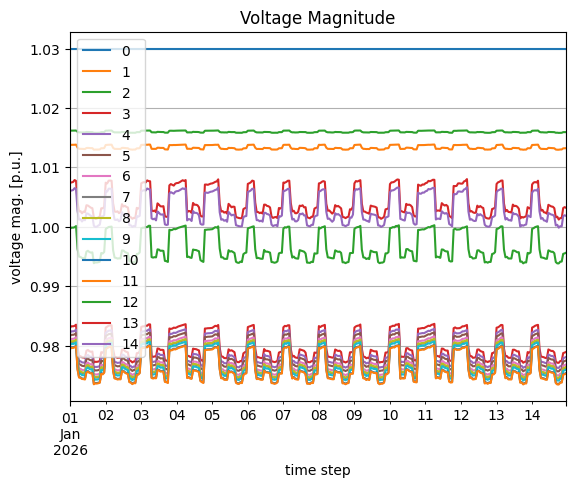

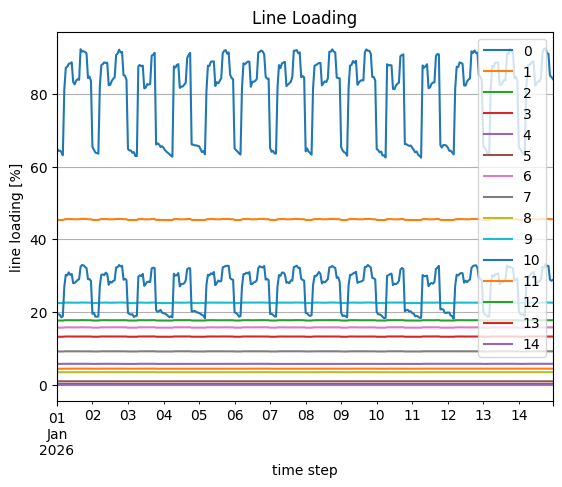

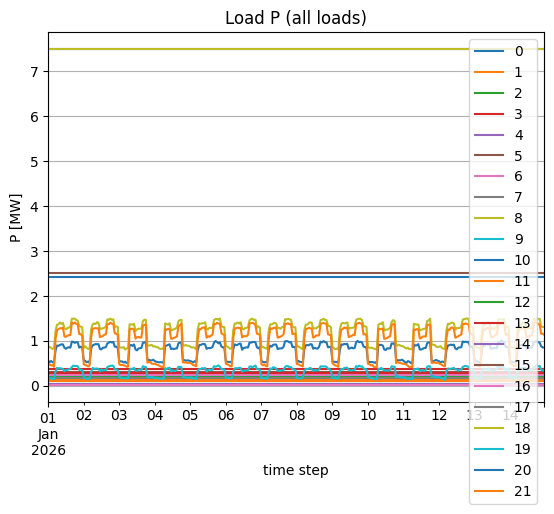

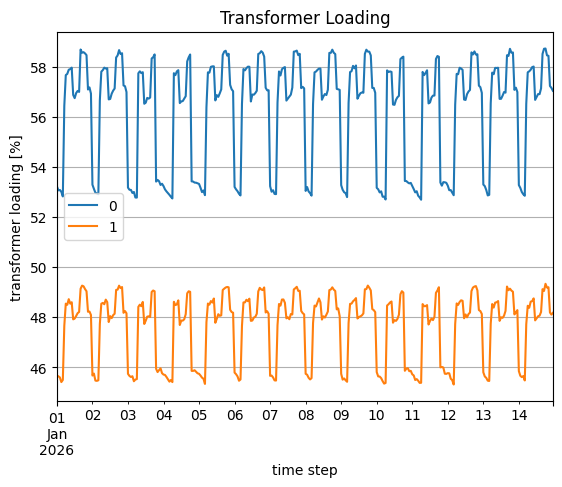

In [36]:
# Voltage results
vm_pu = pd.read_excel(os.path.join(out_dir, "res_bus", "vm_pu.xlsx"), index_col=0)
vm_pu.plot()
plt.xlabel("time step"); plt.ylabel("voltage mag. [p.u.]"); plt.title("Voltage Magnitude"); plt.grid(); plt.show()

# Line loading results
line_loading = pd.read_excel(os.path.join(out_dir, "res_line", "loading_percent.xlsx"), index_col=0)
line_loading.plot()
plt.xlabel("time step"); plt.ylabel("line loading [%]"); plt.title("Line Loading"); plt.grid(); plt.show()

# Load results
load = pd.read_excel(os.path.join(out_dir, "res_load", "p_mw.xlsx"), index_col=0)
load.plot()
plt.xlabel("time step"); plt.ylabel("P [MW]"); plt.title("Load P (all loads)"); plt.grid(); plt.show()

# Transformer loading results
transformer_loading = pd.read_excel(os.path.join(out_dir, "res_trafo", "loading_percent.xlsx"), index_col=0)
transformer_loading.plot()
plt.xlabel("time step"); plt.ylabel("transformer loading [%]"); plt.title("Transformer Loading"); plt.grid(); plt.show()

**From the plots, we can notice that the network doesn't get any overloadings (loading percentage over 100% for each line) every single time. While, if we connected the loads based on the busses power availability (look at file "MAIN_27sept_v1"), we could see that line 0 (so the one between bus 1 and bus 2) was most of the time over 100%, which is not fine. This is probably due to the fact that in the second scenario, the network is unbalanced, meaning that we were adding three loads from the transformer 0 side and just one on the right side (transformer 1). On the other hand, this scenario puts two loads on the left and two loads on the right, making the system more balanced overall. A study was done also forcing all the loads to be placed in different buses, but the results were worse than this configuration.**

### Plot the daily results
From the bi-weekly plots, it can be seen that the daily trend is almost-or the same for each day. Let's have a look in the detail at the first day pattern.

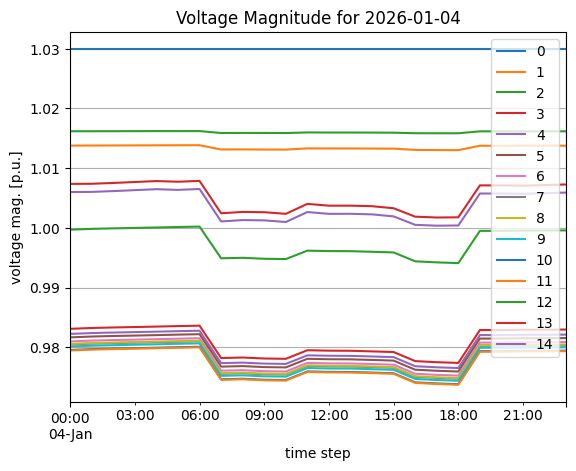

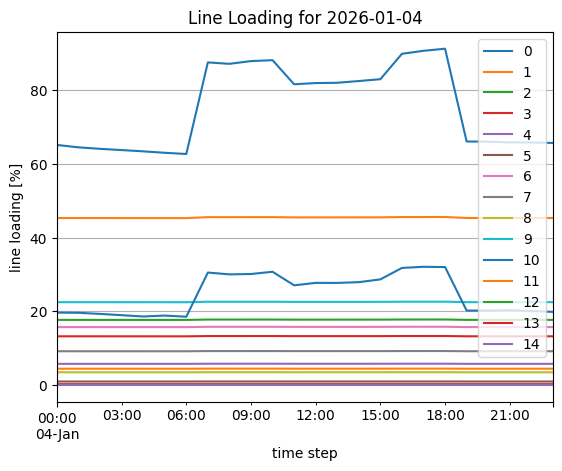

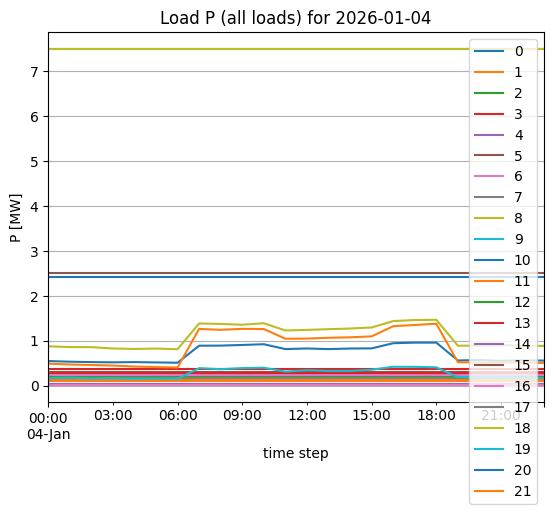

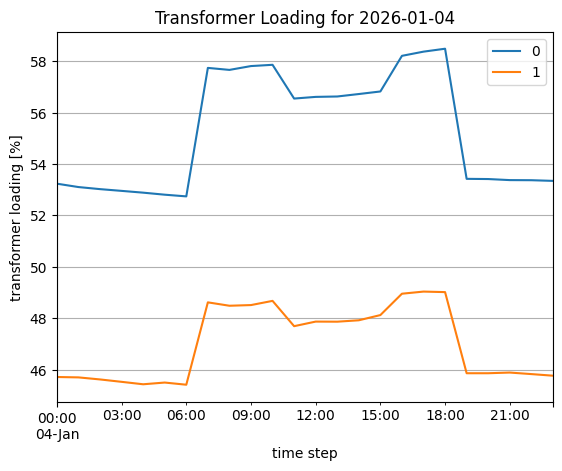

In [37]:
day = '2026-01-04'

# Voltage results
vm_pu_day = vm_pu.loc[day]
vm_pu_day.plot()
plt.xlabel("time step"); plt.ylabel("voltage mag. [p.u.]"); plt.title("Voltage Magnitude for " + day); plt.grid(); plt.legend(loc='upper right'); plt.show()


# Line loading results
line_loading_day = line_loading.loc[day]
line_loading_day.plot()
plt.xlabel("time step"); plt.ylabel("line loading [%]"); plt.title("Line Loading for " + day); plt.grid(); plt.show()

# Load results
load_day = load.loc[day]
load_day.plot()
plt.xlabel("time step"); plt.ylabel("P [MW]"); plt.title("Load P (all loads) for " + day); plt.grid(); plt.show()

# Transformer loading results
# transformer_loading = pd.read_excel(os.path.join(out_dir, "res_trafo", "loading_percent.xlsx"), index_col=0, parse_dates=True)
transformer_loading_day = transformer_loading.loc[day]
transformer_loading_day.plot()
plt.xlabel("time step"); plt.ylabel("transformer loading [%]"); plt.title("Transformer Loading for " + day); plt.grid(); plt.show()


Let's compare the results with the baseline network (Step 1's network)    

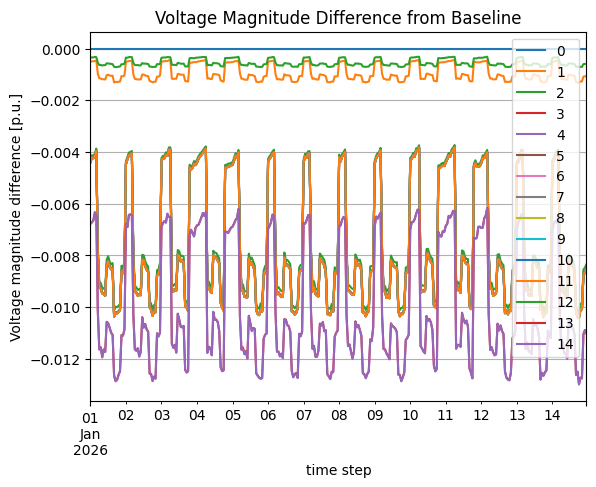

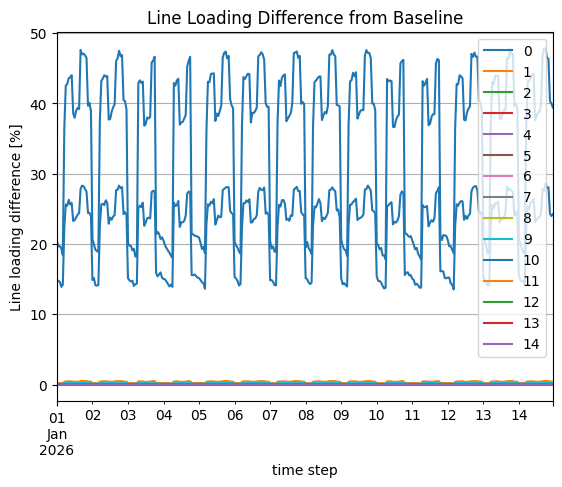

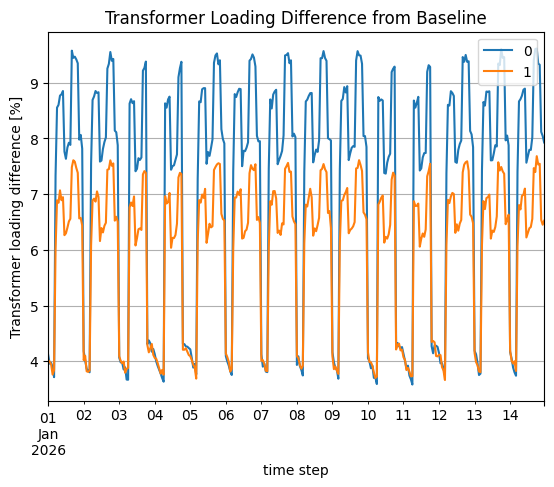

In [38]:
# Extract baseline voltage magnitudes from net_base for each bus
baseline_vm_pu = net_base.res_bus.vm_pu

# Then subtract baseline from each timestamp in your vm_pu dataframe like this:
vm_pu_diff = vm_pu.subtract(baseline_vm_pu, axis=1)

# Plotting
vm_pu_diff.plot()
plt.xlabel("time step"); plt.ylabel("Voltage magnitude difference [p.u.]"); plt.title("Voltage Magnitude Difference from Baseline"); plt.grid(); plt.legend(loc='upper right'); plt.show()

# Extract baseline line loadings from net_base for each line
baseline_line_loading = net_base.res_line.loading_percent

# Then subtract baseline from each timestamp in your loading_percent dataframe like this:
line_loading_diff = line_loading.subtract(baseline_line_loading, axis=1)
 
# Plotting
line_loading_diff.plot()
plt.xlabel("time step"); plt.ylabel("Line loading difference [%]"); plt.title("Line Loading Difference from Baseline"); plt.grid(); plt.legend(loc='upper right'); plt.show()

# Extract baseline transformer loadings from net_base for each transformer
baseline_trafo_loading = net_base.res_trafo.loading_percent

# Subtract baseline from each timestamp in your transformer_loading DataFrame
transformer_loading_diff = transformer_loading.subtract(baseline_trafo_loading, axis=1)

# Plot transformer loading difference
transformer_loading_diff.plot()
plt.xlabel("time step"); plt.ylabel("Transformer loading difference [%]"); plt.title("Transformer Loading Difference from Baseline"); plt.grid(); plt.legend(loc='upper right'); plt.show()

Zoom again for just one day

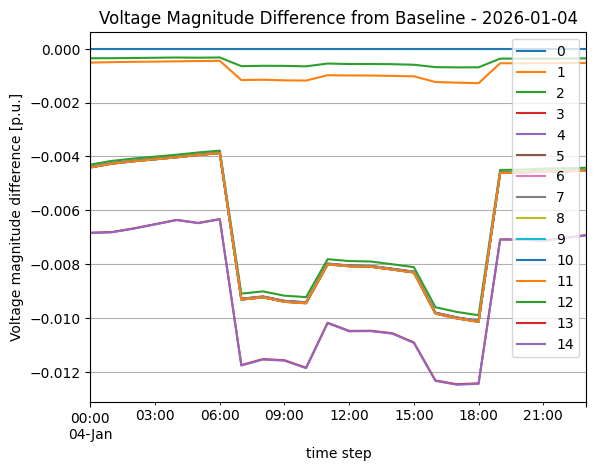

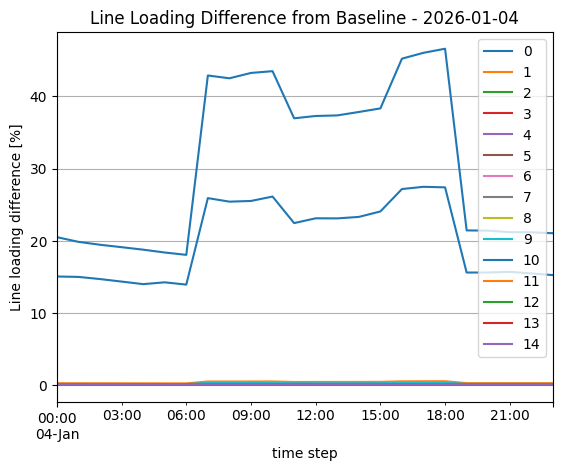

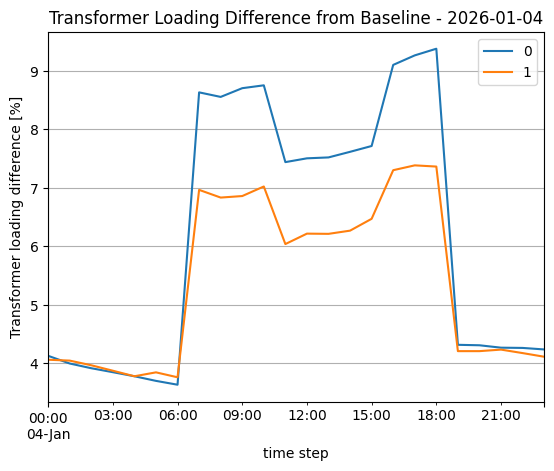

In [39]:
day = '2026-01-04'

# Filter voltage magnitude difference for the specific day
vm_pu_diff_day = vm_pu_diff.loc[vm_pu_diff.index.date == pd.to_datetime(day).date()]

# Plot voltage magnitude difference for the day
vm_pu_diff_day.plot()
plt.xlabel("time step"); plt.ylabel("Voltage magnitude difference [p.u.]"); plt.title(f"Voltage Magnitude Difference from Baseline - {day}"); plt.grid(); plt.legend(loc='upper right'); plt.show()

# Filter line loading difference for the specific day
line_loading_diff_day = line_loading_diff.loc[line_loading_diff.index.date == pd.to_datetime(day).date()]

# Plot line loading difference for the day
line_loading_diff_day.plot()
plt.xlabel("time step"); plt.ylabel("Line loading difference [%]"); plt.title(f"Line Loading Difference from Baseline - {day}"); plt.grid(); plt.legend(loc='upper right'); plt.show()

# Filter transformer loading difference for the specific day
transformer_loading_diff_day = transformer_loading_diff.loc[transformer_loading_diff.index.date == pd.to_datetime(day).date()]

# Plot transformer loading difference for the day
transformer_loading_diff_day.plot()
plt.xlabel("time step"); plt.ylabel("Transformer loading difference [%]"); plt.title(f"Transformer Loading Difference from Baseline - {day}"); plt.grid(); plt.legend(loc='upper right'); plt.show()

## STEP 2.4

Network with freight depot load profiles:  
• 2.4 During which time periods does the network experience the highest stress under contingency conditions with depot loads?  
• Identify the worst-case loading period from the 2-week depot profile analysis.  
• Perform N-1 contingency analysis.  
• Consider voltage limits: maximum 1.1 pu, minimum 0.9 pu, line loading maximum 100%.  
• Compare critical lines with baseline Step 1 results -which additional lines become critical?  

In [40]:
# Exclude first two columns (date and time) for summation
values_df = df_depots.iloc[:, 2:]/1000.0  # Convert kW to MW

# Calculate sum across rows
row_sums = values_df.sum(axis=1)

# Find index of the row with the maximum sum
max_sum_index = row_sums.idxmax()

# Extract date and time corresponding to the max sum row
max_sum_date = df_depots.iloc[max_sum_index, 0]
max_sum_time = df_depots.iloc[max_sum_index, 1]
max_sum_value = row_sums[max_sum_index]

# Extract load values for all depots at max sum timestep
load_at_max = values_df.iloc[max_sum_index]

print(f"Date with max sum: {max_sum_date}")
print(f"Time with max sum: {max_sum_time}")
print(f"Sum of values at max load: {max_sum_value}\n")

print("Load values for each depot at max sum timestep:")
print(load_at_max)

Date with max sum: 2026-01-14 00:00:00
Time with max sum: 18:00:00+01:00
Sum of values at max load: 4.3501263248

Load values for each depot at max sum timestep:
ICA         1.498091
Mathem      0.991397
Postnord    1.404241
Airmee      0.456397
Name: 330, dtype: float64


Let's create a new network to analyse the worst case hour of the dataset (biggest load)

In [41]:
net_worstcase_tf = copy.deepcopy(net_base)

Now adding the Load values for each depot at max sum timestep at the previous selected buses

In [42]:
# Loop through the dictionary and add loads to the net
for depot_name, bus in depot_bus_map.items():
    load_size = load_at_max[depot_name]  # get load value from load_at_max Series for the depot
    add_single_load(net_worstcase_tf, depot_name, load_size, bus)


Added ICA (1.498 MW) to bus 13
Added Airmee (0.456 MW) to bus 13
Added Mathem (0.991 MW) to bus 2
Added Postnord (1.404 MW) to bus 2


Run the powerflow of the worst case scenario 

In [43]:
pp.runpp(net_worstcase_tf)

Create a hourly contengency analysis funtion

In [44]:
DEPOTS = ['ICA', 'Mathem', 'Postnord', 'Airmee']  

def update_loads_for_hour(net, load_row, depot_names=DEPOTS, units="kW"):
    factor = 1 
    for name in depot_names:
        idx = net.load.index[net.load.get('name', pd.Series(index=net.load.index)).eq(name)]
        if len(idx) == 0:
            raise ValueError(
                f"Depot '{name}' not found in net.load['name']. Ensure add_single_load used this name."
            )
        net.load.loc[idx, 'p_mw'] = float(load_row[name]) * factor

def cont_analysis_hourly(net, v_min, v_max, line_loading_limit, trafo_loading_limit,
                         load_profiles, depot_names=DEPOTS, load_units="kW",
                         excluded_lines=(12, 13, 14), verbose_base=True):
  


    if len(net.switch):
        net.switch.loc[:, "closed"] = True

    all_records = []

    for hour_idx, load_row in load_profiles.iterrows():
        # 1) Update depot loads
        update_loads_for_hour(net, load_row, depot_names=depot_names, units=load_units)

        # --- Base-case (no outage) capacity snapshot after adding depots ---
        pp.runpp(net)
        base_line_load = net.res_line.loading_percent if len(net.line) else pd.Series(dtype=float)
        base_max_loading = float(base_line_load.max()) if len(base_line_load) else 0.0
        base_max_idx = base_line_load.idxmax() if len(base_line_load) else None
        base_max_name = (net.line.at[base_max_idx, 'name']
                         if base_max_idx is not None and 'name' in net.line.columns else
                         (str(base_max_idx) if base_max_idx is not None else "N/A"))
        base_margin_to_100 = 100.0 - base_max_loading

        hour_label = load_row['Time'] if 'Time' in load_row else hour_idx
        if verbose_base:
            print(f"[{hour_label}] Base max line load: {base_max_name} {base_max_loading:.1f}%")

                  

        # 2) N-1 over lines
        for line_idx in net.line.index:
            if line_idx in excluded_lines:
                continue

            net.line.at[line_idx, 'in_service'] = False
            try:
                pp.runpp(net)

                bus_v = net.res_bus.vm_pu
                v_viol = ((bus_v < v_min) | (bus_v > v_max)).any()

                line_load = net.res_line.loading_percent
                line_viol = (line_load > line_loading_limit).any()

                other_lines = line_load.drop(line_idx)
                max_other_line_loading = float(other_lines.max()) if len(other_lines) else 0.0
                max_other_idx = other_lines.idxmax() if len(other_lines) else None
                max_other_line_name = (net.line.at[max_other_idx, 'name']
                                       if max_other_idx is not None and 'name' in net.line.columns else
                                       (str(max_other_idx) if max_other_idx is not None else "N/A"))
                # Headroom after the outage on the most-stressed remaining line:
                postcont_margin_to_100 = 100.0 - max_other_line_loading

                trafo_load = (net.res_trafo.loading_percent
                              if len(net.trafo) else pd.Series(dtype=float))
                trafo_viol = (trafo_load > trafo_loading_limit).any() if len(trafo_load) else False

                critical = bool(v_viol or line_viol or trafo_viol)
                if critical:
                    from_bus = net.line.at[line_idx, 'from_bus']
                    to_bus   = net.line.at[line_idx, 'to_bus']
                    max_trafo_loading = float(trafo_load.max()) if len(trafo_load) else None
                    line_name = (net.line.at[line_idx, 'name']
                                 if 'name' in net.line.columns else str(line_idx))

                    all_records.append({
                        'hour': hour_label,
                        'outaged_line_index': line_idx,
                        'outaged_line_name': line_name,
                        'from_bus_voltage': float(bus_v[from_bus]),
                        'to_bus_voltage': float(bus_v[to_bus]),

                        # --- Capacity snapshots ---
                        'base_max_line_loading': base_max_loading,
                        'base_max_line_name': base_max_name,
                        'base_margin_to_100': base_margin_to_100,

                        'max_other_line_loading': max_other_line_loading,
                        'max_other_line_name': max_other_line_name,
                        'postcont_margin_to_100': postcont_margin_to_100,

                        'transformer_loading_max': (float(max_trafo_loading)
                                                    if max_trafo_loading is not None else None),
                        'critical_line': True
                    })
            except Exception as e:
                print(f"Error during PF at hour {hour_label} for line {line_idx}: {e}")
            finally:
                net.line.at[line_idx, 'in_service'] = True

    if not all_records:
        print("No contingencies found across all hours.")
    return pd.DataFrame(all_records)



Run cont_analysis_hourly 

In [45]:
hourly_results= cont_analysis_hourly(net_worstcase_tf, v_min=0.9, v_max=1.1, line_loading_limit=100, trafo_loading_limit=100, load_profiles=hourly_loads)

hourly_results

[00:00:00+01:00] Base max line load: Line 1-2 49.9%
[01:00:00+01:00] Base max line load: Line 1-2 49.3%
[02:00:00+01:00] Base max line load: Line 1-2 49.3%
[03:00:00+01:00] Base max line load: Line 1-2 48.9%
[04:00:00+01:00] Base max line load: Line 1-2 48.3%
[05:00:00+01:00] Base max line load: Line 1-2 63.7%
[06:00:00+01:00] Base max line load: Line 1-2 69.2%
[07:00:00+01:00] Base max line load: Line 1-2 69.3%
[08:00:00+01:00] Base max line load: Line 1-2 70.2%
[09:00:00+01:00] Base max line load: Line 1-2 70.0%
[10:00:00+01:00] Base max line load: Line 1-2 70.3%
[11:00:00+01:00] Base max line load: Line 1-2 65.5%
[12:00:00+01:00] Base max line load: Line 1-2 65.1%
[13:00:00+01:00] Base max line load: Line 1-2 66.0%
[14:00:00+01:00] Base max line load: Line 1-2 66.4%
[15:00:00+01:00] Base max line load: Line 1-2 66.4%
[16:00:00+01:00] Base max line load: Line 1-2 73.6%
[17:00:00+01:00] Base max line load: Line 1-2 73.3%
[18:00:00+01:00] Base max line load: Line 1-2 73.4%
[19:00:00+01

,hour,outaged_line_index,outaged_line_name,from_bus_voltage,to_bus_voltage,base_max_line_loading,base_max_line_name,base_margin_to_100,max_other_line_loading,max_other_line_name,postcont_margin_to_100,transformer_loading_max,critical_line
0,00:00:00+01:00,10,Line 12-13,1.017221,0.928699,49.921085,Line 1-2,50.078915,104.597280,Line 1-2,-4.597280,61.136129,True
1,01:00:00+01:00,10,Line 12-13,1.017221,0.929060,49.344409,Line 1-2,50.655591,103.676957,Line 1-2,-3.676957,60.939809,True
2,02:00:00+01:00,10,Line 12-13,1.017221,0.929280,49.338888,Line 1-2,50.661112,103.507580,Line 1-2,-3.507580,60.904120,True
3,03:00:00+01:00,10,Line 12-13,1.017221,0.930350,48.851567,Line 1-2,51.148433,102.163187,Line 1-2,-2.163187,60.618474,True
4,04:00:00+01:00,10,Line 12-13,1.017221,0.930123,48.343063,Line 1-2,51.656937,101.754924,Line 1-2,-1.754924,60.529871,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,21:00:00+01:00,10,Line 12-13,1.017221,0.910019,67.163299,Line 1-2,32.836701,138.051413,Line 1-2,-38.051413,68.135599,True
632,22:00:00+01:00,0,Line 1-2,1.017380,0.888739,66.781831,Line 1-2,33.218169,104.429322,Line 12-13,-4.429322,69.063170,True
633,22:00:00+01:00,10,Line 12-13,1.017221,0.910603,66.781831,Line 1-2,33.218169,137.180549,Line 1-2,-37.180549,67.955504,True
634,23:00:00+01:00,0,Line 1-2,1.017380,0.889346,66.465625,Line 1-2,33.534375,104.193247,Line 12-13,-4.193247,68.998005,True


In [46]:
count_table = (hourly_results.groupby(['outaged_line_name', 'max_other_line_name']).size().reset_index(name='count'))
print(count_table)


  outaged_line_name max_other_line_name  count
0          Line 1-2          Line 12-13    238
1        Line 12-13            Line 1-2    336
2        Line 13-14            Line 1-2     62


In [47]:
cont_analysis(net_worstcase_tf, v_min=0.9, v_max=1.1, line_loading_limit=100, trafo_loading_limit=100)

Critical contingency found when removing 'Line 1-2':
 - Max loading on other lines: 'Line 12-13' at 104.2 %
 - Voltages: Bus 1 = 1.017 pu, Bus 2 = 0.889 pu
 - Max Transformer loading: 69.0 %
Critical contingency found when removing 'Line 12-13':
 - Max loading on other lines: 'Line 1-2' at 137.0 %
 - Voltages: Bus 12 = 1.017 pu, Bus 13 = 0.910 pu
 - Max Transformer loading: 67.9 %


(   outaged_line_index  from_bus_voltage  to_bus_voltage  \
 0                   0          1.017380        0.889346   
 1                  10          1.017221        0.910348   
 
    max_other_line_loading max_other_line_name  transformer_loading_max  \
 0              104.193247          Line 12-13                68.998005   
 1              137.018438            Line 1-2                67.921465   
 
    critical_line outaged_line_name  
 0           True          Line 1-2  
 1           True        Line 12-13  ,
 None)

## STEP 2.5

Network with freight depot load profiles:  
• 2.5 How does the addition of depot loads affect the network's ability to handle contingencies with strict power quality requirements?  
• Apply stricter limits: maximum voltage 1.05 pu, minimum 0.95 pu, maximum line loading 100%.  
• Perform contingency analysis  
• Compare the network's operational status with and without depot loads. Critically evaluate results and give suggestions  

In [48]:
hourly_results_Step2_5= cont_analysis_hourly(net_worstcase_tf, v_min=0.95, v_max=1.05, line_loading_limit=100, trafo_loading_limit=100, load_profiles=hourly_loads)

hourly_results_Step2_5

[00:00:00+01:00] Base max line load: Line 1-2 49.9%
[01:00:00+01:00] Base max line load: Line 1-2 49.3%
[02:00:00+01:00] Base max line load: Line 1-2 49.3%
[03:00:00+01:00] Base max line load: Line 1-2 48.9%
[04:00:00+01:00] Base max line load: Line 1-2 48.3%
[05:00:00+01:00] Base max line load: Line 1-2 63.7%
[06:00:00+01:00] Base max line load: Line 1-2 69.2%
[07:00:00+01:00] Base max line load: Line 1-2 69.3%
[08:00:00+01:00] Base max line load: Line 1-2 70.2%
[09:00:00+01:00] Base max line load: Line 1-2 70.0%
[10:00:00+01:00] Base max line load: Line 1-2 70.3%
[11:00:00+01:00] Base max line load: Line 1-2 65.5%
[12:00:00+01:00] Base max line load: Line 1-2 65.1%
[13:00:00+01:00] Base max line load: Line 1-2 66.0%
[14:00:00+01:00] Base max line load: Line 1-2 66.4%
[15:00:00+01:00] Base max line load: Line 1-2 66.4%
[16:00:00+01:00] Base max line load: Line 1-2 73.6%
[17:00:00+01:00] Base max line load: Line 1-2 73.3%
[18:00:00+01:00] Base max line load: Line 1-2 73.4%
[19:00:00+01

,hour,outaged_line_index,outaged_line_name,from_bus_voltage,to_bus_voltage,base_max_line_loading,base_max_line_name,base_margin_to_100,max_other_line_loading,max_other_line_name,postcont_margin_to_100,transformer_loading_max,critical_line
0,00:00:00+01:00,0,Line 1-2,1.017380,0.918413,49.921085,Line 1-2,50.078915,78.490357,Line 12-13,21.509643,61.799007,True
1,00:00:00+01:00,10,Line 12-13,1.017221,0.928699,49.921085,Line 1-2,50.078915,104.597280,Line 1-2,-4.597280,61.136129,True
2,01:00:00+01:00,0,Line 1-2,1.017380,0.919425,49.344409,Line 1-2,50.655591,77.735750,Line 12-13,22.264250,61.584670,True
3,01:00:00+01:00,10,Line 12-13,1.017221,0.929060,49.344409,Line 1-2,50.655591,103.676957,Line 1-2,-3.676957,60.939809,True
4,02:00:00+01:00,0,Line 1-2,1.017380,0.919425,49.338888,Line 1-2,50.661112,77.630467,Line 12-13,22.369533,61.554458,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,21:00:00+01:00,10,Line 12-13,1.017221,0.910019,67.163299,Line 1-2,32.836701,138.051413,Line 1-2,-38.051413,68.135599,True
730,22:00:00+01:00,0,Line 1-2,1.017380,0.888739,66.781831,Line 1-2,33.218169,104.429322,Line 12-13,-4.429322,69.063170,True
731,22:00:00+01:00,10,Line 12-13,1.017221,0.910603,66.781831,Line 1-2,33.218169,137.180549,Line 1-2,-37.180549,67.955504,True
732,23:00:00+01:00,0,Line 1-2,1.017380,0.889346,66.465625,Line 1-2,33.534375,104.193247,Line 12-13,-4.193247,68.998005,True


In [49]:
count_table_2_5 = (hourly_results_Step2_5.groupby(['outaged_line_name', 'max_other_line_name']).size().reset_index(name='count'))
print(count_table_2_5)


  outaged_line_name max_other_line_name  count
0          Line 1-2          Line 12-13    336
1        Line 12-13            Line 1-2    336
2        Line 13-14            Line 1-2     62


**Comment and suggestions**  
As seen from point 2.4 and point 2.5, we get specific lines under critical conditions for most of the time (if not all the time) under certain scenarios. This happens to line 1-2 and line 12-13, which are the two main lines that connect the network to the main grid. Since the configuration of the grid is made like this (radial). So, when one of these main lines is shut down, the other one has to handle too much power and voltage problems. Clearly if the line shutted down is the immediate next one to a series configuration, the outcome will be the same (like in this case with line 13-14).  
A suggestion to avoid these overloads/low voltages could be to integrate new physical cables on the lines with overloads and voltage support devices on low voltages lines. Overall, a better solution could be the redistribution of the loads. 

# STEP 3

## STEP 3.1

3.1 Based on the status of network resulting in Step 2, what charging infrastructure should be designed for each depot?  
•a) Analyze the load patterns and characteristics from Step 2 to understand each depot's operational characteristics. Analyze profile to determine fleet size, vehicle types, schedule charging patterns for each company.  
•b) Determine the infrastructure charging loads for each company profile with the efleetscheduler.  
•c) Design the appropriate charging infrastructure design for each depot including:  
•Number of charging points needed  
•Type of chargers  
•Power rating for each charger type  
•Justify design decisions based on observed operational patterns  

Plot just the demanded power from the excel file. 

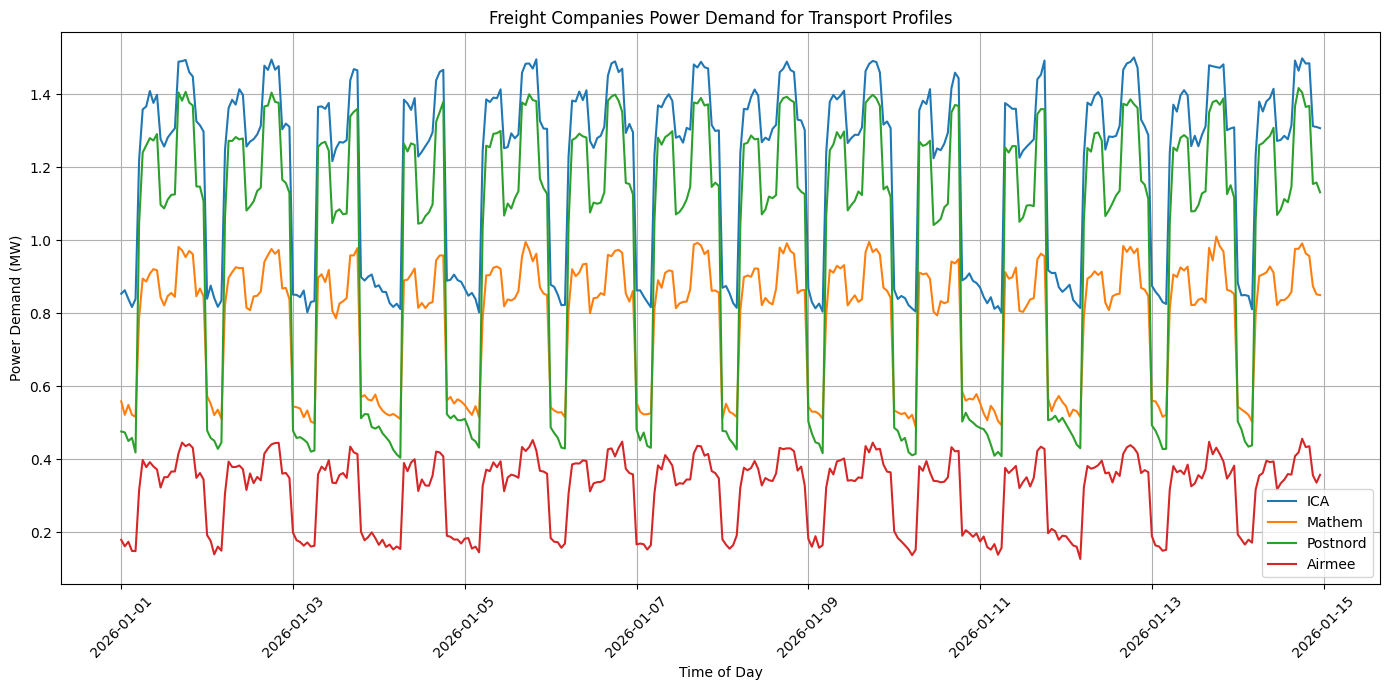

In [50]:
plt.figure(figsize=(14, 7))
for company in needed_cols:
    plt.plot(profiles[company], label=company)
plt.title('Freight Companies Power Demand for Transport Profiles'); plt.xlabel('Time of Day'); plt.ylabel('Power Demand (MW)'); plt.xticks(rotation=45); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

Installing efleetschedule package in the environment

In [51]:
pip install efleetscheduler==1.0.3

Note: you may need to restart the kernel to use updated packages.


### Importing dependencies

In [52]:
import pandas as pd
import numpy as np
import xlsxwriter as xl
import matplotlib.pyplot as plt
import os
from glob import glob
from matplotlib import rcParams
from datetime import datetime
import datetime as dt
import math
from typing import Literal
import time
from matplotlib.ticker import MaxNLocator

import sys
module_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(module_path, 'src')
if src_path not in sys.path:
	sys.path.append(src_path)

from efleetscheduler.schedule_generator_1 import ScheduleGenerator
from efleetscheduler.schedule_configure import scheduletype, vehicletype, companytype
from efleetscheduler.schedule_generator_2 import generate_schedules
from efleetscheduler.generate_graphs import generate_graphs

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
notebook_dir = os.getcwd()

Giving in input the Energy Consumption Factor (from Tutorial 1 point 3).
This factor is used to adjust energy consumption values based on changes in temperature, accounting for environmental and operational variations.

The example uses hourly temperature data from the "Stockholm-Observatorielunden A" measurement station, provided by the Swedish Meteorological and Hydrological Institute (SMHI).

### ICA - Schedule generator configurations

In [53]:
# environment arguments - adjust settings if necessary
env_config_ICA = {"original_seed": 42,  # Seed for RNG - can be set to None so always random (not recommended)
                    
              # settings below if you want to generate new schedules
              "gen_start_date": "2026-01-01 00:00:00",  # As for "Load_profiles_Freight transports"
              "gen_end_date": "2026-01-14 23:00:00",  # # As for "Load_profiles_Freight transports"
              "freq": "h",  # 'h' means hourly frequency.
              
              "EVs": 10, # Number of electric vehicles in the fleet ##CHANGE
                            
              # path to the CSV file with energy consumption factor (the example if for Stockholm 2026)
              # This value can be adjusted to other locations with hourly temperature data
              "consumption_factor_file" : os.path.join(notebook_dir, "Energy_consumption_factor_2026.csv")  #link to the file here
                                         
              }

In [54]:
# Schedule arguments - adjust settings if necessary
sch_config_ICA = {"Vehicles number": 10,  ##CHANGE # Number of vehicles in the fleet (You can choose the number of vehicles you want to generate the schedule for, but it needs to be the same has env_config)
              
              "Type of schedule": {"type a": 0, "type b": 0, "type c": 10},  ##CHANGE NUMBER OF EV # Type A, which consists of a continuous schedule, and Type B, which includes breaks, going to the distribution terminal durind the day.
              
              #type C is Custom Schedule is when you need to createq your own schedule, and it is defined below.
                            
              # Type C is Custom Schedule that needs to be define here:
              
              "Custom Schedule": {"average departure weekday": 5,  # Average departure time on a weekday in hours (0-23)
                                  "std deviation departure weekday": 1,  # Standard deviation of departure time on a weekday in hours
                                  "average return weekday": 23,  # Average return time on a weekday in hours (0-23)
                                  "std deviation return weekday": 1,  # Standard deviation of return time on a weekday in hours
                                  "average departure weekend": 7,  # Average departure time on a weekend in hours (0-23)
                                  "std deviation departure weekend": 1,  # Standard deviation of departure time on a weekend in hours
                                  "average return weekend": 18,  # Average return time on a weekend in hours (0-23)
                                  "std deviation return weekend": 1,  # Standard deviation of return time on a weekend in hours
                                  "minimum departure": 5,  # Minimum departure time in hours (0-23)
                                  "maximum departure": 7,  # Maximum departure time in hours (0-23)
                                  "minimum return": 18,  # Minimum return time in hours (0-23)
                                  "maximum return": 23  # Maximum return time in hours (0-23)
                                  },
              
              "Type of vehicle": {"Renault": 5, "Toyota": 5},  # Renault or Toyota ##CHANGE COMBINATION
              
              "Company type": companytype.Distribution, ##CHANGE # Types of company: Distribution, LineHaul, CraftServWithGoods, CraftServWithoutGoods, Food, Mail, Building, Highdistance, Generalcargo, Nogoodsm, Custom
              
              #"Company type":Custom,  # Custom company type, if you want to generate a custom schedule with your own distance and stops parameters
              "Custom Distance": {"average weekday":120,  # Average distance travelled on a weekday in km
                                "average weekend": 70,  # Average distance travelled on a weekend in km 
                                "standard deviation weekday": 15,  # Standard deviation of distance travelled on a weekday in km
                                "standard deviation weekend": 15,  # Standard deviation of distance travelled on a weekend in
                                "min distance": 30,  # Minimum distance travelled in km
                                "max distance": 300,  # Maximum distance travelled in km  
                                "min distance per hour": 1,  # Minimum distance travelled per hour in km
                                "max distance per hour": 50,  # Maximum distance travelled per hour in km
                                "average stops": 30,  # Average number of stops per day
                                "standard deviation stops": 10  # Standard deviation of number of stops per                  
                                },
              
              "Schedule name": 'schedule_ICA' ##CHANGE # Name of the schedule
                }

In [55]:
schedule_ICA = generate_schedules(env_config_ICA, sch_config_ICA)

### Save parameters files in CVS

In [56]:
# Save individual files for each parameter for both schedules
parameters = ['Distance_km', 'Consumption_kWh', 'Consumption_km', 'Location', 'ChargingStation', 'PowerRating_kW', 'ScheduleType', 'consumption_factor']

for schedule, schedule_name in zip([schedule_ICA], ['ICA']):
    for parameter in parameters:
        # Pivot the table for the current parameter
        pivoted_schedule = schedule.pivot_table(
            index='date', 
            columns='VehicleID', 
            values=parameter, 
            aggfunc='first'
        )

        # Flatten the multi-index columns
        pivoted_schedule.columns = [f'{parameter}_Vehicle_{vehicle}' for vehicle in pivoted_schedule.columns]
        
        # Reset the index to bring 'date' as a column
        pivoted_schedule.reset_index(inplace=True)
        
        # Folder name
        folder_name = f'{schedule_name}'

        # Create and check on the folder Output in data folder in the project root
        output_folder = os.path.join(notebook_dir, 'data', 'Output', folder_name)
        if not os.path.exists(output_folder):
            os.makedirs(output_folder)
        
        # Save each parameter to a separate CSV file in the output_folder
        file_name = os.path.join(output_folder, f'{schedule_name}_all_vehicles_{parameter}.csv')
        pivoted_schedule.to_csv(file_name, index=False)

### Mathem - Schedule generator configurations

In [57]:
# environment arguments - adjust settings if necessary
env_config_Mathem = {"original_seed": 42,  # Seed for RNG - can be set to None so always random (not recommended)
                    
              # settings below if you want to generate new schedules
              "gen_start_date": "2026-01-01 00:00:00",  # As for "Load_profiles_Freight transports"
              "gen_end_date": "2026-01-14 23:00:00",  # # As for "Load_profiles_Freight transports"
              "freq": "h",  # 'h' means hourly frequency.
              
              "EVs": 7, # Number of electric vehicles in the fleet ##CHANGE
                            
              # path to the CSV file with energy consumption factor (the example if for Stockholm 2026)
              # This value can be adjusted to other locations with hourly temperature data
              "consumption_factor_file" : os.path.join(notebook_dir, "Energy_consumption_factor_2026.csv")  #link to the file here
                                         
              }

In [58]:
# Schedule arguments - adjust settings if necessary
sch_config_Mathem = {"Vehicles number": 7,  ##CHANGE # Number of vehicles in the fleet (You can choose the number of vehicles you want to generate the schedule for, but it needs to be the same has env_config)
              
              "Type of schedule": {"type a": 0, "type b": 0, "type c": 7},  ##CHANGE NUMBER OF EV # Type A, which consists of a continuous schedule, and Type B, which includes breaks, going to the distribution terminal durind the day.
              
              #type C is Custom Schedule is when you need to createq your own schedule, and it is defined below.
                            
              # Type C is Custom Schedule that needs to be define here:
              
              "Custom Schedule": {"average departure weekday": 7,  # Average departure time on a weekday in hours (0-23)
                                  "std deviation departure weekday": 1,  # Standard deviation of departure time on a weekday in hours
                                  "average return weekday": 22,  # Average return time on a weekday in hours (0-23)
                                  "std deviation return weekday": 1,  # Standard deviation of return time on a weekday in hours
                                  "average departure weekend": 8,  # Average departure time on a weekend in hours (0-23)
                                  "std deviation departure weekend": 1,  # Standard deviation of departure time on a weekend in hours
                                  "average return weekend": 18,  # Average return time on a weekend in hours (0-23)
                                  "std deviation return weekend": 1,  # Standard deviation of return time on a weekend in hours
                                  "minimum departure": 7,  # Minimum departure time in hours (0-23)
                                  "maximum departure": 8,  # Maximum departure time in hours (0-23)
                                  "minimum return": 18,  # Minimum return time in hours (0-23)
                                  "maximum return": 22  # Maximum return time in hours (0-23)
                                  },
              
              "Type of vehicle": {"Renault": 4, "Toyota": 3},  # Renault or Toyota ##CHANGE COMBINATION
              
              "Company type": companytype.Food, ##CHANGE # Types of company: Distribution, LineHaul, CraftServWithGoods, CraftServWithoutGoods, Food, Mail, Building, Highdistance, Generalcargo, Nogoodsm, Custom
              
              #"Company type":Custom,  # Custom company type, if you want to generate a custom schedule with your own distance and stops parameters
              "Custom Distance": {"average weekday":120,  # Average distance travelled on a weekday in km
                                "average weekend": 70,  # Average distance travelled on a weekend in km 
                                "standard deviation weekday": 15,  # Standard deviation of distance travelled on a weekday in km
                                "standard deviation weekend": 15,  # Standard deviation of distance travelled on a weekend in
                                "min distance": 30,  # Minimum distance travelled in km
                                "max distance": 300,  # Maximum distance travelled in km  
                                "min distance per hour": 1,  # Minimum distance travelled per hour in km
                                "max distance per hour": 50,  # Maximum distance travelled per hour in km
                                "average stops": 30,  # Average number of stops per day
                                "standard deviation stops": 10  # Standard deviation of number of stops per                  
                                },
              
              "Schedule name": 'schedule_Mathem' ##CHANGE # Name of the schedule
                }

In [59]:
schedule_Mathem = generate_schedules(env_config_Mathem, sch_config_Mathem)

### Save parameters files in CVS

In [60]:
# Save individual files for each parameter for both schedules
parameters = ['Distance_km', 'Consumption_kWh', 'Consumption_km', 'Location', 'ChargingStation', 'PowerRating_kW', 'ScheduleType', 'consumption_factor']

for schedule, schedule_name in zip([schedule_Mathem], ['Mathem']):
    for parameter in parameters:
        # Pivot the table for the current parameter
        pivoted_schedule = schedule.pivot_table(
            index='date', 
            columns='VehicleID', 
            values=parameter, 
            aggfunc='first'
        )

        # Flatten the multi-index columns
        pivoted_schedule.columns = [f'{parameter}_Vehicle_{vehicle}' for vehicle in pivoted_schedule.columns]
        
        # Reset the index to bring 'date' as a column
        pivoted_schedule.reset_index(inplace=True)
        
        # Folder name
        folder_name = f'{schedule_name}'

        # Create and check on the folder Output in data folder in the project root
        output_folder = os.path.join(notebook_dir, 'data', 'Output', folder_name)
        if not os.path.exists(output_folder):
            os.makedirs(output_folder)
        
        # Save each parameter to a separate CSV file in the output_folder
        file_name = os.path.join(output_folder, f'{schedule_name}_all_vehicles_{parameter}.csv')
        pivoted_schedule.to_csv(file_name, index=False)

### Postnord - Schedule generator configurations

In [61]:
# environment arguments - adjust settings if necessary
env_config_Postnord = {"original_seed": 42,  # Seed for RNG - can be set to None so always random (not recommended)
                    
              # settings below if you want to generate new schedules
              "gen_start_date": "2026-01-01 00:00:00",  # As for "Load_profiles_Freight transports"
              "gen_end_date": "2026-01-14 23:00:00",  # # As for "Load_profiles_Freight transports"
              "freq": "h",  # 'h' means hourly frequency.
              
              "EVs": 8, # Number of electric vehicles in the fleet ##CHANGE
                            
              # path to the CSV file with energy consumption factor (the example if for Stockholm 2026)
              # This value can be adjusted to other locations with hourly temperature data
              "consumption_factor_file" : os.path.join(notebook_dir, "Energy_consumption_factor_2026.csv")  #link to the file here
                                         
              }

In [62]:
# Schedule arguments - adjust settings if necessary
sch_config_Postnord = {"Vehicles number": 8,  ##CHANGE # Number of vehicles in the fleet (You can choose the number of vehicles you want to generate the schedule for, but it needs to be the same has env_config)
              
              "Type of schedule": {"type a": 0, "type b": 0, "type c": 8},  ##CHANGE NUMBER OF EV # Type A, which consists of a continuous schedule, and Type B, which includes breaks, going to the distribution terminal durind the day.
              
              #type C is Custom Schedule is when you need to createq your own schedule, and it is defined below.
                            
              # Type C is Custom Schedule that needs to be define here:
              
              "Custom Schedule": {"average departure weekday": 4,  # Average departure time on a weekday in hours (0-23)
                                  "std deviation departure weekday": 1,  # Standard deviation of departure time on a weekday in hours
                                  "average return weekday": 22,  # Average return time on a weekday in hours (0-23)
                                  "std deviation return weekday": 1,  # Standard deviation of return time on a weekday in hours
                                  "average departure weekend": 4,  # Average departure time on a weekend in hours (0-23)
                                  "std deviation departure weekend": 1,  # Standard deviation of departure time on a weekend in hours
                                  "average return weekend": 22,  # Average return time on a weekend in hours (0-23)
                                  "std deviation return weekend": 1,  # Standard deviation of return time on a weekend in hours
                                  "minimum departure": 4,  # Minimum departure time in hours (0-23)
                                  "maximum departure": 4,  # Maximum departure time in hours (0-23)
                                  "minimum return": 22,  # Minimum return time in hours (0-23)
                                  "maximum return": 22  # Maximum return time in hours (0-23)
                                  },
              
              "Type of vehicle": {"Renault": 4, "Toyota": 4},  # Renault or Toyota ##CHANGE COMBINATION
              
              "Company type": companytype.Mail, ##CHANGE # Types of company: Distribution, LineHaul, CraftServWithGoods, CraftServWithoutGoods, Food, Mail, Building, Highdistance, Generalcargo, Nogoodsm, Custom
              
              #"Company type":Custom,  # Custom company type, if you want to generate a custom schedule with your own distance and stops parameters
              "Custom Distance": {"average weekday":120,  # Average distance travelled on a weekday in km
                                "average weekend": 70,  # Average distance travelled on a weekend in km 
                                "standard deviation weekday": 15,  # Standard deviation of distance travelled on a weekday in km
                                "standard deviation weekend": 15,  # Standard deviation of distance travelled on a weekend in
                                "min distance": 30,  # Minimum distance travelled in km
                                "max distance": 300,  # Maximum distance travelled in km  
                                "min distance per hour": 1,  # Minimum distance travelled per hour in km
                                "max distance per hour": 50,  # Maximum distance travelled per hour in km
                                "average stops": 30,  # Average number of stops per day
                                "standard deviation stops": 10  # Standard deviation of number of stops per                  
                                },
              
              "Schedule name": 'schedule_Postnord' ##CHANGE # Name of the schedule
                }

In [63]:
schedule_Postnord = generate_schedules(env_config_Postnord, sch_config_Postnord)

### Save parameters files in CVS

In [64]:
# Save individual files for each parameter for both schedules
parameters = ['Distance_km', 'Consumption_kWh', 'Consumption_km', 'Location', 'ChargingStation', 'PowerRating_kW', 'ScheduleType', 'consumption_factor']

for schedule, schedule_name in zip([schedule_Postnord], ['Postnord']):
    for parameter in parameters:
        # Pivot the table for the current parameter
        pivoted_schedule = schedule.pivot_table(
            index='date', 
            columns='VehicleID', 
            values=parameter, 
            aggfunc='first'
        )

        # Flatten the multi-index columns
        pivoted_schedule.columns = [f'{parameter}_Vehicle_{vehicle}' for vehicle in pivoted_schedule.columns]
        
        # Reset the index to bring 'date' as a column
        pivoted_schedule.reset_index(inplace=True)
        
        # Folder name
        folder_name = f'{schedule_name}'

        # Create and check on the folder Output in data folder in the project root
        output_folder = os.path.join(notebook_dir, 'data', 'Output', folder_name)
        if not os.path.exists(output_folder):
            os.makedirs(output_folder)
        
        # Save each parameter to a separate CSV file in the output_folder
        file_name = os.path.join(output_folder, f'{schedule_name}_all_vehicles_{parameter}.csv')
        pivoted_schedule.to_csv(file_name, index=False)

### Airmee - Schedule generator configurations

In [65]:
# environment arguments - adjust settings if necessary
env_config_Airmee = {"original_seed": 42,  # Seed for RNG - can be set to None so always random (not recommended)
                    
              # settings below if you want to generate new schedules
              "gen_start_date": "2026-01-01 00:00:00",  # As for "Load_profiles_Freight transports"
              "gen_end_date": "2026-01-14 23:00:00",  # # As for "Load_profiles_Freight transports"
              "freq": "h",  # 'h' means hourly frequency.
              
              "EVs": 4, # Number of electric vehicles in the fleet ##CHANGE
                            
              # path to the CSV file with energy consumption factor (the example if for Stockholm 2026)
              # This value can be adjusted to other locations with hourly temperature data
              "consumption_factor_file" : os.path.join(notebook_dir, "Energy_consumption_factor_2026.csv")  #link to the file here
                                         
              }

In [66]:
# Schedule arguments - adjust settings if necessary
sch_config_Airmee = {"Vehicles number": 4,  ##CHANGE # Number of vehicles in the fleet (You can choose the number of vehicles you want to generate the schedule for, but it needs to be the same has env_config)
              
              "Type of schedule": {"type a": 0, "type b": 0, "type c": 4},  ##CHANGE NUMBER OF EV # Type A, which consists of a continuous schedule, and Type B, which includes breaks, going to the distribution terminal durind the day.
              
              #type C is Custom Schedule is when you need to createq your own schedule, and it is defined below.
                            
              # Type C is Custom Schedule that needs to be define here:
              
              "Custom Schedule": {"average departure weekday": 8,  # Average departure time on a weekday in hours (0-23)
                                  "std deviation departure weekday": 1,  # Standard deviation of departure time on a weekday in hours
                                  "average return weekday": 20,  # Average return time on a weekday in hours (0-23)
                                  "std deviation return weekday": 1,  # Standard deviation of return time on a weekday in hours
                                  "average departure weekend": 9,  # Average departure time on a weekend in hours (0-23)
                                  "std deviation departure weekend": 1,  # Standard deviation of departure time on a weekend in hours
                                  "average return weekend": 17,  # Average return time on a weekend in hours (0-23)
                                  "std deviation return weekend": 1,  # Standard deviation of return time on a weekend in hours
                                  "minimum departure": 8,  # Minimum departure time in hours (0-23)
                                  "maximum departure": 9,  # Maximum departure time in hours (0-23)
                                  "minimum return": 17,  # Minimum return time in hours (0-23)
                                  "maximum return": 20  # Maximum return time in hours (0-23)
                                  },
              
              "Type of vehicle": {"Renault": 2, "Toyota": 2},  # Renault or Toyota ##CHANGE COMBINATION
              
              "Company type": companytype.Mail, ##CHANGE # Types of company: Distribution, LineHaul, CraftServWithGoods, CraftServWithoutGoods, Food, Mail, Building, Highdistance, Generalcargo, Nogoodsm, Custom
              
              #"Company type":Custom,  # Custom company type, if you want to generate a custom schedule with your own distance and stops parameters
              "Custom Distance": {"average weekday":120,  # Average distance travelled on a weekday in km
                                "average weekend": 70,  # Average distance travelled on a weekend in km 
                                "standard deviation weekday": 15,  # Standard deviation of distance travelled on a weekday in km
                                "standard deviation weekend": 15,  # Standard deviation of distance travelled on a weekend in
                                "min distance": 30,  # Minimum distance travelled in km
                                "max distance": 300,  # Maximum distance travelled in km  
                                "min distance per hour": 1,  # Minimum distance travelled per hour in km
                                "max distance per hour": 50,  # Maximum distance travelled per hour in km
                                "average stops": 30,  # Average number of stops per day
                                "standard deviation stops": 10  # Standard deviation of number of stops per                  
                                },
              
              "Schedule name": 'schedule_Airmee' ##CHANGE # Name of the schedule
                }

In [67]:
schedule_Airmee = generate_schedules(env_config_Airmee, sch_config_Airmee)

### Save parameters files in CVS

In [68]:
# Save individual files for each parameter for both schedules
parameters = ['Distance_km', 'Consumption_kWh', 'Consumption_km', 'Location', 'ChargingStation', 'PowerRating_kW', 'ScheduleType', 'consumption_factor']

for schedule, schedule_name in zip([schedule_Airmee], ['Airmee']):
    for parameter in parameters:
        # Pivot the table for the current parameter
        pivoted_schedule = schedule.pivot_table(
            index='date', 
            columns='VehicleID', 
            values=parameter, 
            aggfunc='first'
        )

        # Flatten the multi-index columns
        pivoted_schedule.columns = [f'{parameter}_Vehicle_{vehicle}' for vehicle in pivoted_schedule.columns]
        
        # Reset the index to bring 'date' as a column
        pivoted_schedule.reset_index(inplace=True)
        
        # Folder name
        folder_name = f'{schedule_name}'

        # Create and check on the folder Output in data folder in the project root
        output_folder = os.path.join(notebook_dir, 'data', 'Output', folder_name)
        if not os.path.exists(output_folder):
            os.makedirs(output_folder)
        
        # Save each parameter to a separate CSV file in the output_folder
        file_name = os.path.join(output_folder, f'{schedule_name}_all_vehicles_{parameter}.csv')
        pivoted_schedule.to_csv(file_name, index=False)

### Graphs generation per schedule
If you have more than one type of fleet, just need to add the folder name in the next cell.

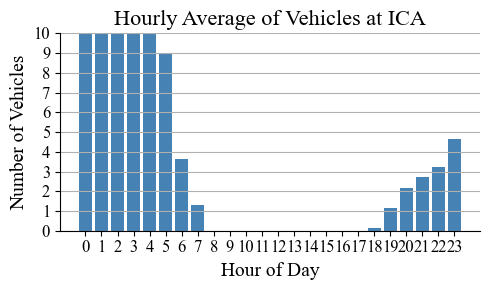

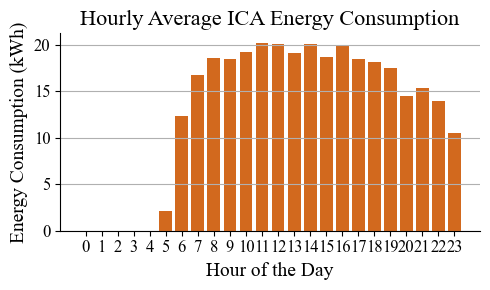

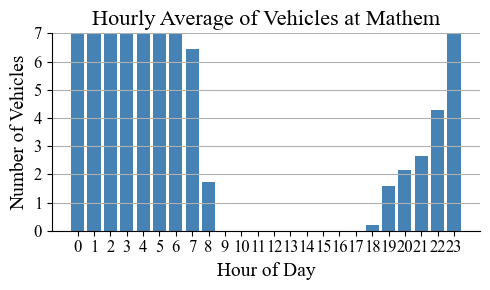

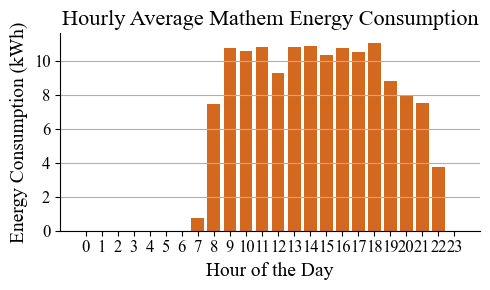

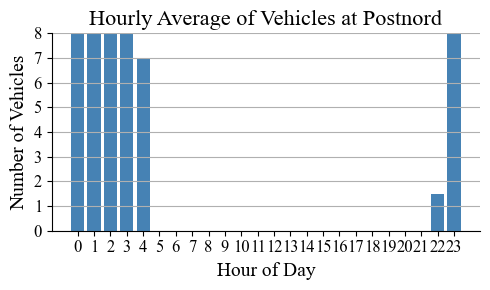

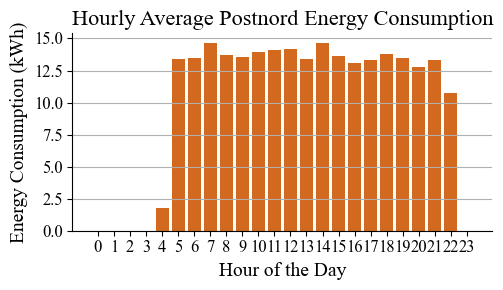

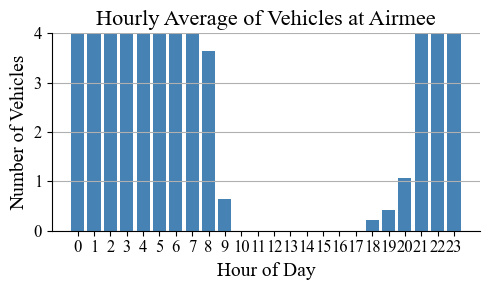

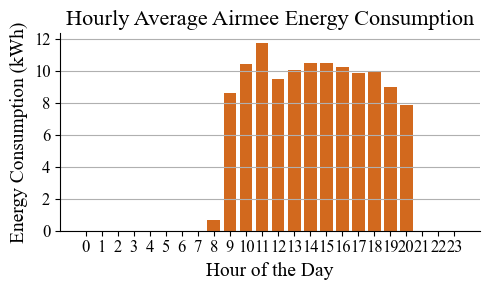

In [69]:
folders = ['schedule_ICA', 'schedule_Mathem', 'schedule_Postnord', 'schedule_Airmee']

for folder in folders:
    schedule_name = folder.split("_")[1]
    output_folder = os.path.join(notebook_dir, 'data', 'Output', schedule_name)
    distance_file_path = os.path.join(output_folder, f'{schedule_name}_all_vehicles_Distance_km.csv')
    charging_file_path = os.path.join(output_folder, f'{schedule_name}_all_vehicles_ChargingStation.csv')
    consumption_file_path = os.path.join(output_folder, f'{schedule_name}_all_vehicles_Consumption_kWh.csv')

    
    generate_graphs(distance_file_path, charging_file_path, consumption_file_path, folder, output_folder, schedule_name)


### Step 3.1(c): design Charger based on the hourly load data from the peak load (EAFO/AFIR aligned)

For this point, we're initially assuming a number of chargers equal to the number of vehicles. This assumption could be later modified if the networks will face overloads or contingencies.

Due to the batteries of both types of vehicles, we choose to select the following charger: Fast AC rechargingpoint, triple-phase, P > 22 kW

In [70]:
# The charging power per station is chosen to be 22 Fast AC rechargingpoint, triple-phase. It's chosen a 22 kW because the vehicles stay for a long time in the depot, 
# and using a lower power output even if for a longer time, it's retained to cause less stress to the grid.
charging_power = 22  # kW

In [71]:
def calculate_charging_power(company, env_config):
    # File Directory
    base = os.path.join("data", "Output", company)
    fn_cons = f"{company}_all_vehicles_Consumption_kWh.csv"
    fn_pw = f"{company}_all_vehicles_PowerRating_kW.csv"
    fn_loc = f"{company}_all_vehicles_Location.csv"
    fn_chg = f"{company}_all_vehicles_ChargingStation.csv"

    # Read data
    cons = pd.read_csv(os.path.join(base, fn_cons))
    pw = pd.read_csv(os.path.join(base, fn_pw))
    loc = pd.read_csv(os.path.join(base, fn_loc))

    # Conversion to datetime
    cons['date'] = pd.to_datetime(cons['date'])
    pw['date'] = pd.to_datetime(pw['date'])
    loc['date'] = pd.to_datetime(loc['date'])

    # Calculating hourly charging load for each vehicle
    charging_load = loc.drop(columns=['date']).values * pw.drop(columns=['date']).values
    total_hourly_load = charging_load.sum(axis=1)

    hourly_load_df = pd.DataFrame({
        'date': cons['date'],
        'Total_Charging_Load_kW': total_hourly_load
    })

    print(hourly_load_df.head(24))

    # Baseline scenario: number of charging point
    n_chargers = env_config[company]['EVs'] if company in env_config else len(loc.columns) - 1

    # Read consumption data and charging state
    consumption_df = cons.copy()
    charging_df = pd.read_csv(os.path.join(base, fn_chg))

    # Convert date and set to index
    for df in [consumption_df, charging_df]:
        df['date'] = pd.to_datetime(df['date'])
        df.set_index('date', inplace=True)

    # Uniform columns name with vehicles
    vehicles = [col.replace('Consumption_kWh_', '').replace('ChargingStation_', '') for col in consumption_df.columns]
    consumption_df.columns = vehicles
    charging_df.columns = vehicles

    # charging_power should be defined elsewhere (kW)
    max_charge_power = charging_power

    # Initialize dataframe
    charging_power_df = pd.DataFrame(index=charging_df.index, columns=vehicles).astype(float)

    for vehicle in vehicles:
        charge_needed = 0.0
        charge_start_index = None

        for i in range(len(charging_df)):
            charging_state = charging_df[vehicle].iloc[i]

            # Start charging
            if charging_state == 1 and charge_start_index is None:
                charge_start_index = i
                last_non_charging_index = i - 1
                previous_leave_index = last_non_charging_index
                while previous_leave_index >= 0 and charging_df[vehicle].iloc[previous_leave_index] == 0:
                    previous_leave_index -= 1
                start_charge_period = previous_leave_index + 1
                end_charge_period = last_non_charging_index + 1
                charge_needed = consumption_df[vehicle].iloc[start_charge_period:end_charge_period].sum()

            # End charging
            if charging_state == 0 and charge_start_index is not None:
                charge_length = i - charge_start_index
                idx_range = list(range(charge_start_index, i))
                remaining_charge = charge_needed
                for real_idx in idx_range:
                    if remaining_charge > charging_power:
                        charging_power_df.loc[charging_power_df.index[real_idx], vehicle] = charging_power
                        remaining_charge -= charging_power
                    else:
                        charging_power_df.loc[charging_power_df.index[real_idx], vehicle] = remaining_charge
                        remaining_charge = 0
                charge_start_index = None
                charge_needed = 0.0

        # Handle final ongoing charging period
        if charge_start_index is not None:
            idx_range = list(range(charge_start_index, len(charging_df)))
            remaining_charge = charge_needed
            for real_idx in idx_range:
                if remaining_charge > charging_power:
                    charging_power_df.loc[charging_power_df.index[real_idx], vehicle] = charging_power
                    remaining_charge -= charging_power
                else:
                    charging_power_df.loc[charging_power_df.index[real_idx], vehicle] = remaining_charge
                    remaining_charge = 0

    # Change NaN to 0.0
    charging_power_df.fillna(0.0, inplace=True)

    # Save results as Excel
    out_excel = f"{company}_charging_power_output.xlsx"
    charging_power_df.to_excel(os.path.join(base, out_excel))

    print(f"(Saved to Excel: {os.path.join(base, out_excel)})")

    return charging_power_df

In [72]:
calculate_charging_power("ICA", env_config_ICA)

                  date  Total_Charging_Load_kW
0  2026-01-01 00:00:00                     900
1  2026-01-01 01:00:00                     900
2  2026-01-01 02:00:00                     900
3  2026-01-01 03:00:00                     900
4  2026-01-01 04:00:00                     900
5  2026-01-01 05:00:00                     900
6  2026-01-01 06:00:00                     100
7  2026-01-01 07:00:00                       0
8  2026-01-01 08:00:00                       0
9  2026-01-01 09:00:00                       0
10 2026-01-01 10:00:00                       0
11 2026-01-01 11:00:00                       0
12 2026-01-01 12:00:00                       0
13 2026-01-01 13:00:00                       0
14 2026-01-01 14:00:00                       0
15 2026-01-01 15:00:00                       0
16 2026-01-01 16:00:00                       0
17 2026-01-01 17:00:00                       0
18 2026-01-01 18:00:00                       0
19 2026-01-01 19:00:00                       0
20 2026-01-01

,Vehicle_0,Vehicle_1,Vehicle_2,Vehicle_3,Vehicle_4,Vehicle_5,Vehicle_6,Vehicle_7,Vehicle_8,Vehicle_9
date,,,,,,,,,,
2026-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
2026-01-14 19:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-14 20:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-14 21:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [73]:
calculate_charging_power("Airmee",env_config_Airmee)

                  date  Total_Charging_Load_kW
0  2026-01-01 00:00:00                     360
1  2026-01-01 01:00:00                     360
2  2026-01-01 02:00:00                     360
3  2026-01-01 03:00:00                     360
4  2026-01-01 04:00:00                     360
5  2026-01-01 05:00:00                     360
6  2026-01-01 06:00:00                     360
7  2026-01-01 07:00:00                     360
8  2026-01-01 08:00:00                     360
9  2026-01-01 09:00:00                       0
10 2026-01-01 10:00:00                       0
11 2026-01-01 11:00:00                       0
12 2026-01-01 12:00:00                       0
13 2026-01-01 13:00:00                       0
14 2026-01-01 14:00:00                       0
15 2026-01-01 15:00:00                       0
16 2026-01-01 16:00:00                       0
17 2026-01-01 17:00:00                       0
18 2026-01-01 18:00:00                       0
19 2026-01-01 19:00:00                       0
20 2026-01-01

,Vehicle_0,Vehicle_1,Vehicle_2,Vehicle_3
date,,,,
2026-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000
2026-01-01 01:00:00,0.000000,0.000000,0.000000,0.000000
2026-01-01 02:00:00,0.000000,0.000000,0.000000,0.000000
2026-01-01 03:00:00,0.000000,0.000000,0.000000,0.000000
2026-01-01 04:00:00,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...
2026-01-14 19:00:00,0.000000,0.000000,0.000000,0.000000
2026-01-14 20:00:00,0.000000,0.000000,0.000000,22.000000
2026-01-14 21:00:00,22.000000,22.000000,22.000000,22.000000


In [74]:
calculate_charging_power("Mathem", env_config_Mathem)

                  date  Total_Charging_Load_kW
0  2026-01-01 00:00:00                     620
1  2026-01-01 01:00:00                     620
2  2026-01-01 02:00:00                     620
3  2026-01-01 03:00:00                     620
4  2026-01-01 04:00:00                     620
5  2026-01-01 05:00:00                     620
6  2026-01-01 06:00:00                     620
7  2026-01-01 07:00:00                     620
8  2026-01-01 08:00:00                       0
9  2026-01-01 09:00:00                       0
10 2026-01-01 10:00:00                       0
11 2026-01-01 11:00:00                       0
12 2026-01-01 12:00:00                       0
13 2026-01-01 13:00:00                       0
14 2026-01-01 14:00:00                       0
15 2026-01-01 15:00:00                       0
16 2026-01-01 16:00:00                       0
17 2026-01-01 17:00:00                       0
18 2026-01-01 18:00:00                       0
19 2026-01-01 19:00:00                       0
20 2026-01-01

,Vehicle_0,Vehicle_1,Vehicle_2,Vehicle_3,Vehicle_4,Vehicle_5,Vehicle_6
date,,,,,,,
2026-01-01 00:00:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0
2026-01-01 01:00:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0
2026-01-01 02:00:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0
2026-01-01 03:00:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0
2026-01-01 04:00:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...
2026-01-14 19:00:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0
2026-01-14 20:00:00,0.000000,15.911752,0.00000,0.000000,0.000000,0.000000,0.0
2026-01-14 21:00:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0


In [75]:
calculate_charging_power("Postnord", env_config_Postnord)

                  date  Total_Charging_Load_kW
0  2026-01-01 00:00:00                     720
1  2026-01-01 01:00:00                     720
2  2026-01-01 02:00:00                     720
3  2026-01-01 03:00:00                     720
4  2026-01-01 04:00:00                     720
5  2026-01-01 05:00:00                       0
6  2026-01-01 06:00:00                       0
7  2026-01-01 07:00:00                       0
8  2026-01-01 08:00:00                       0
9  2026-01-01 09:00:00                       0
10 2026-01-01 10:00:00                       0
11 2026-01-01 11:00:00                       0
12 2026-01-01 12:00:00                       0
13 2026-01-01 13:00:00                       0
14 2026-01-01 14:00:00                       0
15 2026-01-01 15:00:00                       0
16 2026-01-01 16:00:00                       0
17 2026-01-01 17:00:00                       0
18 2026-01-01 18:00:00                       0
19 2026-01-01 19:00:00                       0
20 2026-01-01

,Vehicle_0,Vehicle_1,Vehicle_2,Vehicle_3,Vehicle_4,Vehicle_5,Vehicle_6,Vehicle_7
date,,,,,,,,
2026-01-01 00:00:00,0.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
2026-01-01 01:00:00,0.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
2026-01-01 02:00:00,0.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
2026-01-01 03:00:00,0.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
2026-01-01 04:00:00,0.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
2026-01-14 19:00:00,0.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
2026-01-14 20:00:00,0.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
2026-01-14 21:00:00,0.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0


Now sum all the vehicles' consumption for each freight and put them all in a single table/excel file

In [76]:
def combine_hourly_sums_from_depots(depot_names, base_output_folder, suffix='_charging_power_output.xlsx', output_filename='combined_hourly_sums.xlsx'):
    
    combined_df = None

    for depot in depot_names:
        file_path = os.path.join(base_output_folder, depot, depot + suffix)
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"File not found: {file_path}")
        df = pd.read_excel(file_path)
        datetime_col = df.columns[0]
        df['sum'] = df.iloc[:, 1:].sum(axis=1)

        if combined_df is None:
            combined_df = df[[datetime_col, 'sum']].copy()
            combined_df.rename(columns={'sum': f'Total_{depot}'}, inplace=True)
        else:
            if not (combined_df[datetime_col] == df[datetime_col]).all():
                raise ValueError(f"DateTime mismatch tra file!")
            combined_df[f'Total_{depot}'] = df['sum']

    out_path = os.path.join(base_output_folder, output_filename)
    combined_df.to_excel(out_path, index=False)
    print(f'Combined file saved in {out_path}')
    return combined_df


In [77]:
depots = ['ICA', 'Postnord', 'Mathem', 'Airmee']
base_output = os.path.join(notebook_dir, 'data', 'Output')


combine_hourly_sums_depots = combine_hourly_sums_from_depots(depots, base_output)

Combined file saved in /Users/michelangeloinze/Desktop/Optmization of Energy Networks/Project/Group20_code/Step1_to_Step4/Step1_to_Step4/data/Output/combined_hourly_sums.xlsx


In [78]:
out_path = os.path.join(base_output, "combine_hourly_sums_depots.xlsx")
combine_hourly_sums_depots.to_excel(out_path, index=False)
print(f'combine_hourly_sums_depots file saved in {out_path}')

print(combine_hourly_sums_depots.head(24))


combine_hourly_sums_depots file saved in /Users/michelangeloinze/Desktop/Optmization of Energy Networks/Project/Group20_code/Step1_to_Step4/Step1_to_Step4/data/Output/combine_hourly_sums_depots.xlsx
                  date  Total_ICA  Total_Postnord  Total_Mathem  Total_Airmee
0  2026-01-01 00:00:00   0.000000        0.000000      0.000000      0.000000
1  2026-01-01 01:00:00   0.000000        0.000000      0.000000      0.000000
2  2026-01-01 02:00:00   0.000000        0.000000      0.000000      0.000000
3  2026-01-01 03:00:00   0.000000        0.000000      0.000000      0.000000
4  2026-01-01 04:00:00   0.000000        0.000000      0.000000      0.000000
5  2026-01-01 05:00:00   0.000000        0.000000      0.000000      0.000000
6  2026-01-01 06:00:00   0.000000        0.000000      0.000000      0.000000
7  2026-01-01 07:00:00   0.000000        0.000000      0.000000      0.000000
8  2026-01-01 08:00:00   0.000000        0.000000      0.000000      0.000000
9  2026-01-01 09:00:0

In [79]:
# Create a new dataframe starting from the datetime
freight_load_and_charging = pd.DataFrame()
freight_load_and_charging['date'] = combine_hourly_sums_depots['date']  # add the first datetime column which is the same in both datasets

freight_load_and_charging['ICA'] = combine_hourly_sums_depots['Total_ICA'].values / 1000 + profiles['ICA'].values
freight_load_and_charging['Mathem'] = combine_hourly_sums_depots['Total_Mathem'].values / 1000 + profiles['Mathem'].values
freight_load_and_charging['Postnord'] = combine_hourly_sums_depots['Total_Postnord'].values / 1000 + profiles['Postnord'].values
freight_load_and_charging['Airmee'] = combine_hourly_sums_depots['Total_Airmee'].values / 1000 + profiles['Airmee'].values

print(freight_load_and_charging.head())

# Saving as an excel
#base_output = os.path.join(notebook_dir, 'data', 'Output')
out_path = os.path.join(base_output, "freight_load_and_charging.xlsx")
freight_load_and_charging.to_excel(out_path, index=False)
print(f'freight_load_and_charging file saved in {out_path}')


                 date       ICA    Mathem  Postnord    Airmee
0 2026-01-01 00:00:00  0.853470  0.558823  0.476323  0.179549
1 2026-01-01 01:00:00  0.862975  0.521902  0.473712  0.161848
2 2026-01-01 02:00:00  0.839105  0.549134  0.450265  0.174293
3 2026-01-01 03:00:00  0.817137  0.521987  0.458649  0.149116
4 2026-01-01 04:00:00  0.838922  0.516426  0.418630  0.148731
freight_load_and_charging file saved in /Users/michelangeloinze/Desktop/Optmization of Energy Networks/Project/Group20_code/Step1_to_Step4/Step1_to_Step4/data/Output/freight_load_and_charging.xlsx


### Now proceeding with the Time-Series with the new dataset cointaning the existing loads plus the charging power

In [80]:
df_charge = pd.read_excel(os.path.join(base_output, "freight_load_and_charging.xlsx"))

# Build profiles DataFrame directly (kW -> MW)
profiles_charge = df_charge[["ICA","Mathem","Postnord","Airmee"]] 

profiles_charge.head(24)

,ICA,Mathem,Postnord,Airmee
0,0.853470,0.558823,0.476323,0.179549
1,0.862975,0.521902,0.473712,0.161848
2,0.839105,0.549134,0.450265,0.174293
3,0.817137,0.521987,0.458649,0.149116
4,0.838922,0.516426,0.418630,0.148731
5,1.219844,0.788451,1.045728,0.315488
6,1.358134,0.894910,1.240317,0.398194
7,1.366522,0.886890,1.260259,0.378633
8,1.408640,0.908408,1.279600,0.392371
9,1.376122,0.920890,1.272979,0.380523


**Connect depot load profiles at the buses identified in Step 2.1.**

In [81]:
# create a new network for the time series simulation
net_ts_charge = copy.deepcopy(net_base)

In [82]:
# 1. We add the loads to the selected buses
for depot, bus_id in depot_bus_map.items():
    pp.create_load(
        net_ts_charge, 
        bus=bus_id, 
        p_mw=profiles_charge[f"{depot}"].iloc[0],  # initial load value
        q_mvar=0, 
        name=depot
    )

# 2. Connect the profiles with ConstControl
ds = DFData(profiles_charge)
for depot in depot_bus_map.keys():
    load_idx = net_ts_charge.load.index[net_ts_charge.load.name == depot][0]
    ConstControl(
        net_ts_charge,
        element="load",
        variable="p_mw",
        element_index=[load_idx],
        data_source=ds,
        profile_name=[f"{depot}"]
    )

print("Depot loads created and connected with profiles.")


Depot loads created and connected with profiles.


**Perform hourly load flow analysis for the complete 2-week period.**


In [83]:

needed_cols = ["ICA", "Mathem", "Postnord", "Airmee"]

n_steps = min(len(profiles_charge), 14 * 24)
profiles_ts_charge = profiles_charge[needed_cols].iloc[:n_steps].copy() # first 14 days

time_steps = profiles_ts_charge.index

# 3) Creates DFData 
ds_charge = DFData(profiles_ts_charge)



**Perform hourly load flow analysis for the complete 2-week period.**

In [84]:
needed_cols = ["ICA", "Mathem", "Postnord", "Airmee"]

n_steps = min(len(profiles_charge), 14 * 24)
profiles_ts_charge = profiles_charge[needed_cols].iloc[:n_steps].copy() # first 14 days

time_steps = profiles_ts_charge.index

# 3) Creates DFData 
ds_charge = DFData(profiles_ts_charge)



Note from the time_series tutorial:
*The DFData(profiles) converts the Dataframe to the required format for the controllers. Note that the controller*

In [85]:
# 4) Connect the profiles with ConstControl (integer index 0..N-1)
import os
import pandas as pd

# 0) Clear any existing controllers to avoid conflicts with outdated indices/DataSources
if hasattr(net_ts_charge, "controller") and len(net_ts_charge.controller):
    net_ts_charge.controller.drop(net_ts_charge.controller.index, inplace=True)

# 1) Normalize ds_charge.df: use index 0..N-1 and keep only the required columns
ds_charge.df = ds_charge.df.copy()

# Keep only the necessary columns (if specified)
if 'needed_cols' in locals():
    missing = [c for c in needed_cols if c not in ds_charge.df.columns]
    if missing:
        raise ValueError(f"The following profiles are missing from ds_charge.df: {missing}")
    ds_charge.df = ds_charge.df[needed_cols]

# Reset index to 0..N-1
ds_charge.df.reset_index(drop=True, inplace=True)

# Use this exact index as time steps for the entire simulation
time_steps = ds_charge.df.index  # RangeIndex(0, N)

# 2) Create ConstControl for each depot/column
for name in needed_cols:
    # Find the corresponding load index in the network
    load_idx = int(net_ts_charge.load.index[net_ts_charge.load.name == name][0])
    ConstControl(
        net_ts_charge,
        element="load",
        variable="p_mw",
        element_index=[load_idx],
        data_source=ds_charge,
        profile_name=[name]
    )

# 3) Create results folder
out_dir = os.path.join(os.getcwd(), "results_charging")
os.makedirs(out_dir, exist_ok=True)

# 4) OutputWriter and run_timeseries with the SAME time_steps
ow = OutputWriter(
    net_ts_charge,
    time_steps=time_steps,
    output_path=out_dir,
    output_file_type=".xlsx",
    log_variables=list()
)

ow.log_variable('res_load', 'p_mw')
ow.log_variable('res_bus', 'vm_pu')
ow.log_variable('res_line', 'loading_percent')
ow.log_variable('res_line', 'i_ka')
ow.log_variable('res_trafo', 'loading_percent')

# Run the time series simulation
run_timeseries(net_ts_charge, time_steps=time_steps)

print(f"Results saved in: {out_dir}")


100%|██████████| 336/336 [00:01<00:00, 282.65it/s]

Results saved in: /Users/michelangeloinze/Desktop/Optmization of Energy Networks/Project/Group20_code/Step1_to_Step4/Step1_to_Step4/results_charging


In [86]:
print("\n=== FINAL net_ts_chargeWORK SUMMARY ===")
print("Not added loads:")
for key, value in not_added_loads.items():
    print(f"{key}: {value}")
print(f"Total active power demand: {net_ts_charge.load.p_mw.sum():.3f} MW")
print(f"Total reactive power demand: {net_ts_charge.load.q_mvar.sum():.3f} Mvar")
print(f"Total number of loads: {len(net_ts_charge.load)}")
print(f"Minimum bus voltage: {net_ts_charge.res_bus.vm_pu.min():.3f} pu")
print(f"Maximum line loading: {net_ts_charge.res_line.loading_percent.max():.1f}%")


=== FINAL net_ts_chargeWORK SUMMARY ===
Not added loads:
Mathem: 1.0099493720000001
Postnord: 1.416676579
Total active power demand: 26.307 MW
Total reactive power demand: 5.520 Mvar
Total number of loads: 22
Minimum bus voltage: 0.974 pu
Maximum line loading: 89.1%


### Plot of the results


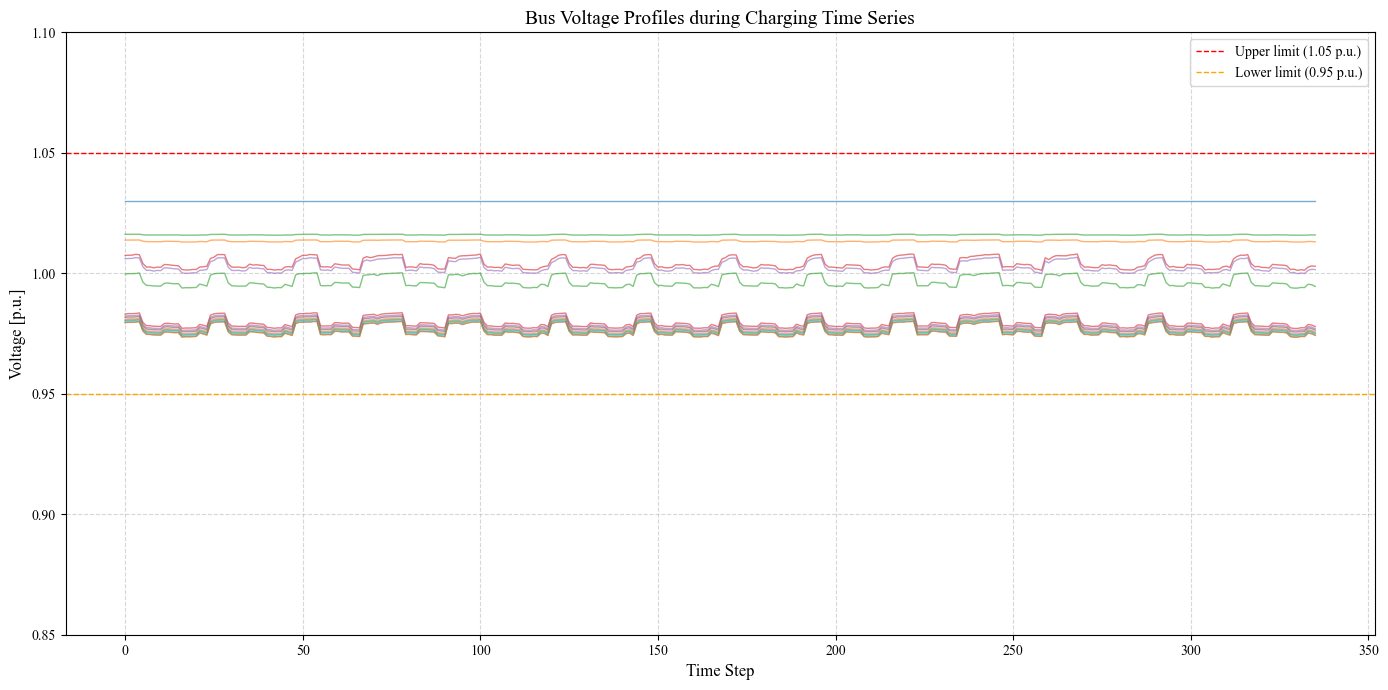

In [87]:
# Path to results from the "charging" time series
results_dir = os.path.join(os.getcwd(), "results_charging", "res_bus")
res_bus_path = os.path.join(results_dir, "vm_pu.xlsx")

# Load the results
res_bus = pd.read_excel(res_bus_path, index_col=0)

# Plot voltage profiles for all buses
plt.figure(figsize=(14, 7))
for col in res_bus.columns:
    plt.plot(res_bus[col], alpha=0.6, linewidth=1)

plt.title('Bus Voltage Profiles during Charging Time Series', fontsize=14)
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Voltage [p.u.]', fontsize=12)
plt.ylim(0.85, 1.1)  # useful range to visualize voltage deviations
plt.grid(True, linestyle='--', alpha=0.5)

# Optional reference lines for voltage limits
plt.axhline(1.05, color='red', linestyle='--', linewidth=1, label='Upper limit (1.05 p.u.)')
plt.axhline(0.95, color='orange', linestyle='--', linewidth=1, label='Lower limit (0.95 p.u.)')
plt.legend()

plt.tight_layout()
plt.show()

## Line Loading

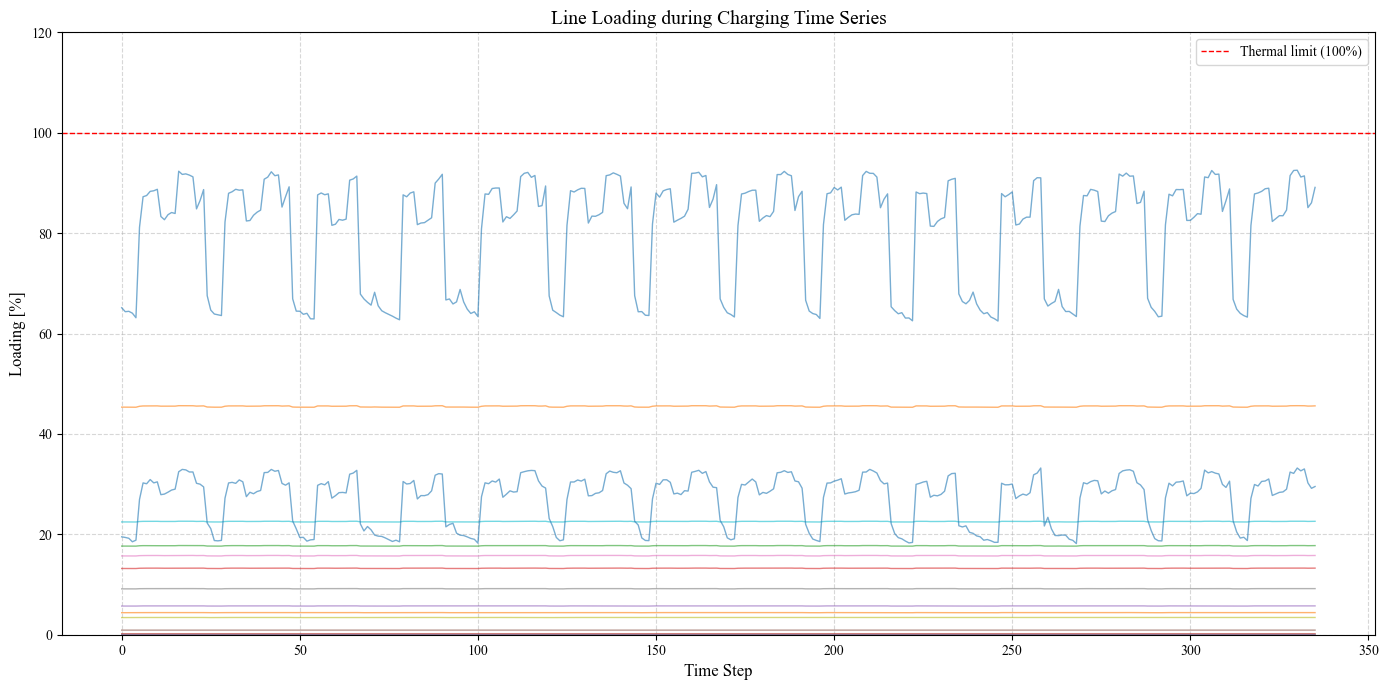

In [88]:
# Load line loading results
results_dir = os.path.join(os.getcwd(), "results_charging", "res_line")
res_line_path = os.path.join(results_dir, "loading_percent.xlsx")
res_line = pd.read_excel(res_line_path, index_col=0)

# Plot
plt.figure(figsize=(14, 7))
for col in res_line.columns:
    plt.plot(res_line[col], alpha=0.6, linewidth=1)

plt.title('Line Loading during Charging Time Series', fontsize=14)
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Loading [%]', fontsize=12)
plt.ylim(0, 120)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(100, color='red', linestyle='--', linewidth=1, label='Thermal limit (100%)')
plt.legend()
plt.tight_layout()
plt.show()

### Transformer Loading


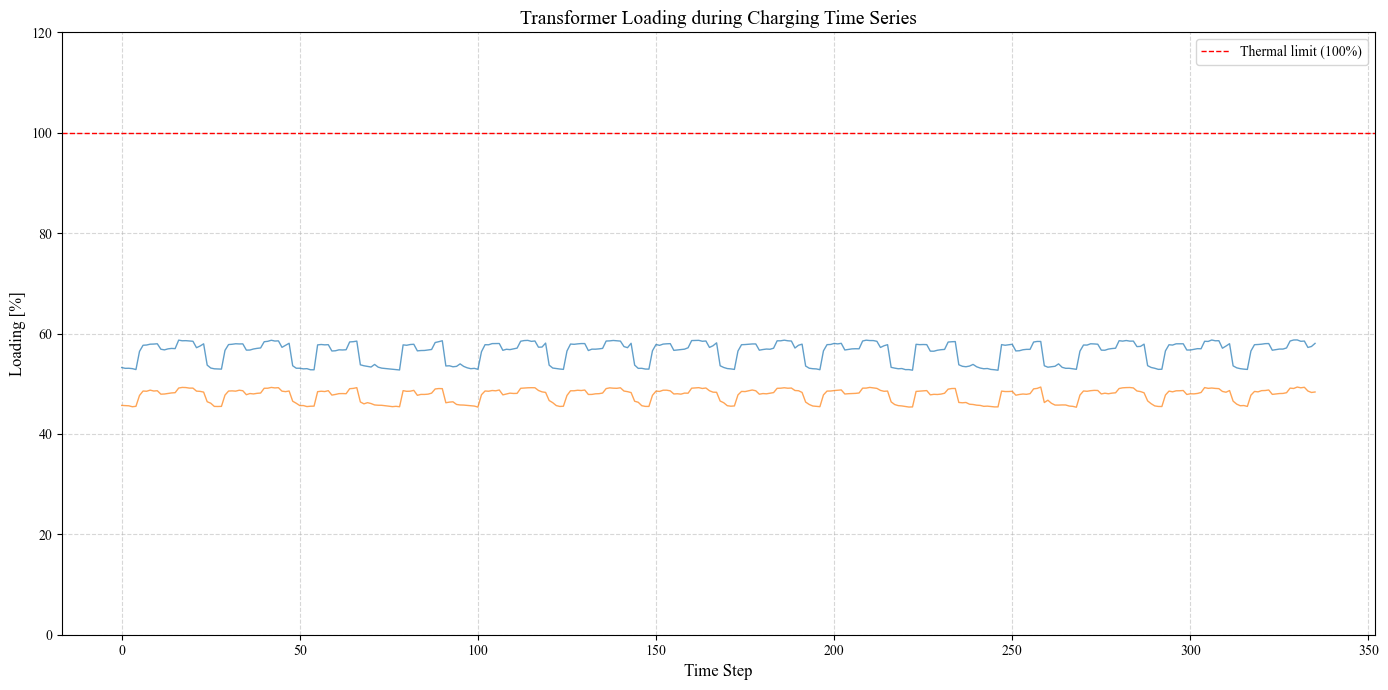

In [89]:
# Load transformer loading results
results_dir = os.path.join(os.getcwd(), "results_charging", "res_trafo")
res_trafo_path = os.path.join(results_dir, "loading_percent.xlsx")
res_trafo = pd.read_excel(res_trafo_path, index_col=0)

# Plot
plt.figure(figsize=(14, 7))
for col in res_trafo.columns:
    plt.plot(res_trafo[col], alpha=0.7, linewidth=1)

plt.title('Transformer Loading during Charging Time Series', fontsize=14)
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Loading [%]', fontsize=12)
plt.ylim(0, 120)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(100, color='red', linestyle='--', linewidth=1, label='Thermal limit (100%)')
plt.legend()
plt.tight_layout()
plt.show()


## Load Power


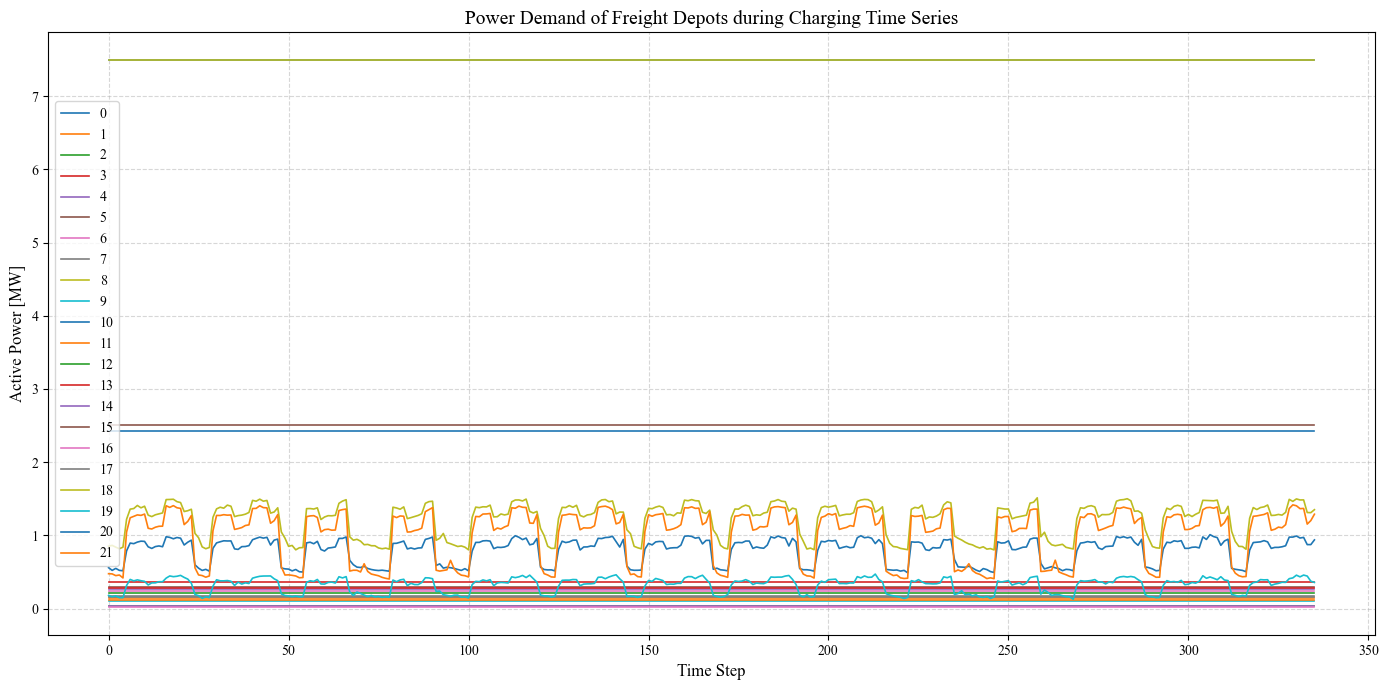

In [90]:
# Load power demand of freight depots
results_dir = os.path.join(os.getcwd(), "results_charging", "res_load")
res_load_path = os.path.join(results_dir, "p_mw.xlsx")
res_load = pd.read_excel(res_load_path, index_col=0)

# Plot
plt.figure(figsize=(14, 7))
for col in res_load.columns:
    plt.plot(res_load[col], label=col, linewidth=1.2)

plt.title('Power Demand of Freight Depots during Charging Time Series', fontsize=14)
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Active Power [MW]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


### Step 3.3 and 3.4 

3.3 How does your charging infrastructure design affect the network's contingency performance?  
Perform N -1 contingency analysis.
•Use the same contingency procedure from Step 1 for all 12 lines for this network.  
•Consider voltage limits: maximum 1.1 pu, minimum 0.9 pu, maximum line loading 100%.  
•Identify which network elements become critical with your designed charging loads.  
•Compare results with Step 2 contingency analysis -how much worse does contingency performance become?  

3.4 Is your charging infrastructure design feasible under strict power quality requirements during contingencies?  
•Apply stricter limits: maximum voltage 1.05 pu, minimum 0.95 pu, maximum line loading 100%.  
•Perform contingency analysis during peak uncontrolled charging periods with your design.  
•If violations occur, consider if you need to: (Need to discuss, no need to add elements to network)  
    •Modify your charging infrastructure design (fewer/smaller chargers)  
    •Select different connection points  
    •Recommend network reinforcements   
•Justify your final charging infrastructure design based on network capability.  

In [91]:
hourly_results_Step3_3=cont_analysis_hourly(net_ts_charge, 0.95, 1.05, 100, 100, load_profiles=profiles_ts_charge)
hourly_results_Step3_3

[0] Base max line load: Line 1-2 44.8%
[1] Base max line load: Line 1-2 44.1%
[2] Base max line load: Line 1-2 44.1%
[3] Base max line load: Line 1-2 43.6%
[4] Base max line load: Line 1-2 43.0%
[5] Base max line load: Line 1-2 59.5%
[6] Base max line load: Line 1-2 65.3%
[7] Base max line load: Line 1-2 65.4%
[8] Base max line load: Line 1-2 66.3%
[9] Base max line load: Line 1-2 66.1%
[10] Base max line load: Line 1-2 66.4%
[11] Base max line load: Line 1-2 61.4%
[12] Base max line load: Line 1-2 61.0%
[13] Base max line load: Line 1-2 61.9%
[14] Base max line load: Line 1-2 62.4%
[15] Base max line load: Line 1-2 62.3%
[16] Base max line load: Line 1-2 69.9%
[17] Base max line load: Line 1-2 69.6%
[18] Base max line load: Line 1-2 69.6%
[19] Base max line load: Line 1-2 69.3%
[20] Base max line load: Line 1-2 69.0%
[21] Base max line load: Line 1-2 63.4%
[22] Base max line load: Line 1-2 64.6%
[23] Base max line load: Line 1-2 66.0%
[24] Base max line load: Line 1-2 47.6%
[25] Base 

,hour,outaged_line_index,outaged_line_name,from_bus_voltage,to_bus_voltage,base_max_line_loading,base_max_line_name,base_margin_to_100,max_other_line_loading,max_other_line_name,postcont_margin_to_100,transformer_loading_max,critical_line
0,0,0,Line 1-2,1.017380,0.945546,44.765312,Line 1-2,55.234688,70.522142,Line 12-13,29.477858,59.656313,True
1,1,0,Line 1-2,1.017380,0.946521,44.134733,Line 1-2,55.865267,69.734093,Line 12-13,30.265907,59.442393,True
2,2,0,Line 1-2,1.017380,0.946521,44.127237,Line 1-2,55.872763,69.620337,Line 12-13,30.379663,59.411727,True
3,3,0,Line 1-2,1.017380,0.947314,43.587871,Line 1-2,56.412129,68.577584,Line 12-13,31.422416,59.129433,True
4,4,0,Line 1-2,1.017380,0.948197,43.032929,Line 1-2,56.967071,68.149807,Line 12-13,31.850193,59.012815,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,333,10,Line 12-13,1.017221,0.934354,63.644216,Line 1-2,36.355784,130.421983,Line 1-2,-30.421983,66.460358,True
579,334,0,Line 1-2,1.017380,0.915029,63.950238,Line 1-2,36.049762,98.924270,Line 12-13,1.075730,67.373768,True
580,334,10,Line 12-13,1.017221,0.935675,63.950238,Line 1-2,36.049762,129.746850,Line 1-2,-29.746850,66.321380,True
581,335,0,Line 1-2,1.017380,0.910920,66.361220,Line 1-2,33.638780,102.070464,Line 12-13,-2.070464,68.232500,True


In [92]:
count_table_3_3 = (hourly_results_Step3_3.groupby(['outaged_line_name', 'max_other_line_name']).size().reset_index(name='count'))
print(count_table_3_3)

  outaged_line_name max_other_line_name  count
0          Line 1-2          Line 12-13    336
1        Line 12-13            Line 1-2    247


# STEP 4 
## Market-Driven Smart Charging Optimization.
In this step, students develop and implement cost-optimized charging strategies by integrating real
Nordic electricity market price data with the charging infrastructure they designed in Step 3.
The main objective is to demonstrate how economic optimization through smart charging can
simultaneously reduce operational costs and improve electrical network performance compared to
uncontrolled charging, while ensuring the system remains reliable under contingency conditions.
The overall aim of this step is:
• Learn to integrate electricity market data into charging optimization.
• Understand the relationship between economic optimization and network performance.
• Develop skills in m ulti-constraint optimization problems.
Step 4 includes 4 sub -steps.

### 4.1 How can day-ahead electricity market prices be used to optimize charging costs across all depots?
 - Import Nordic electricity market (Nord Pool) hourly price data. (check group description for season and zones)-Sweden has four zones
 - Develop optimization algorithm considering:
    - Hourly electricity prices
    - Vehicle departure schedules
    - Battery charging requirements
    - Network capacity constraints from Step 3

**We are Group 20- SE4 - 1 Week from winter + 1 Week from summer**

#### Import of Nordic electricity market hourly price data 
Data imported for the week of 01 January 2024 for winter and for the week of 

In [93]:

# File name
FILE = "Day-ahead Prices_202401010000-202501010000.xlsx"

# Read the Excel file, skipping the first 7 rows and using only the first two columns
df_raw = pd.read_excel(FILE, skiprows=7, usecols="A:B", names=["MTU", "price"])

# Detect date rows

mask_dates = df_raw["MTU"].astype(str).str.match(r"\d{2}\.\d{2}\.\d{4}")
current_date = None
rows = []

for _, row in df_raw.iterrows():
    val = str(row["MTU"])
    # If it is a date (row like "01.01.2024")
    if "." in val and ":" not in val:
        current_date = pd.to_datetime(val, format="%d.%m.%Y")
        continue
    # If it is a time range (row like "00:00 - 01:00")
    if current_date is not None and ":" in val:
        start_hour = val.split(" - ")[0]
        timestamp = pd.to_datetime(f"{current_date.strftime('%Y-%m-%d')} {start_hour}",
                                   format="%Y-%m-%d %H:%M")
        rows.append((timestamp, row["price"]))

df = pd.DataFrame(rows, columns=["datetime", "price"])
df = df.sort_values("datetime").reset_index(drop=True)
df = df.set_index("datetime")

# Quick sanity check
print(df.head(24))



                     price
datetime                  
2024-01-02 00:00:00  38.00
2024-01-02 01:00:00  33.56
2024-01-02 02:00:00  32.03
2024-01-02 03:00:00  32.29
2024-01-02 04:00:00  36.70
2024-01-02 05:00:00  41.72
2024-01-02 06:00:00  49.18
2024-01-02 07:00:00  58.75
2024-01-02 08:00:00  65.67
2024-01-02 09:00:00  66.11
2024-01-02 10:00:00  68.98
2024-01-02 11:00:00  73.54
2024-01-02 12:00:00  78.16
2024-01-02 13:00:00  78.87
2024-01-02 14:00:00  79.24
2024-01-02 15:00:00  79.96
2024-01-02 16:00:00  81.46
2024-01-02 17:00:00  80.92
2024-01-02 18:00:00  74.95
2024-01-02 19:00:00  63.18
2024-01-02 20:00:00  57.11
2024-01-02 21:00:00  48.04
2024-01-02 22:00:00  40.99
2024-01-02 23:00:00  38.35


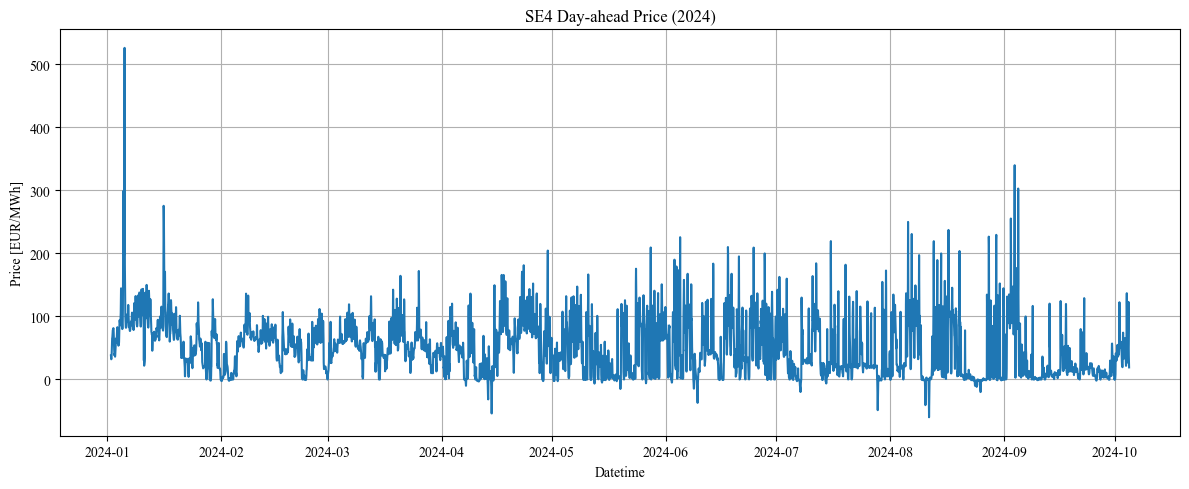

In [94]:
# Ensure index is datetime and price is numeric
df.index = pd.to_datetime(df.index, errors="coerce")
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Drop bad rows and sort (note: 'datetime' is the index, so don't put it in subset)
df = df.dropna(subset=["price"]).sort_index()

# Plot
plt.figure(figsize=(12,5))
plt.plot(df.index, df["price"])
plt.title("SE4 Day-ahead Price (2024)")
plt.xlabel("Datetime")
plt.ylabel("Price [EUR/MWh]")
plt.grid(True)
plt.tight_layout()
plt.show()


We are now creating two data frames, one for the summer and one for the winter week, adjusting the time steps in order to have hourly time steps coherent with the network data resolution.


In [95]:
# EDIT THESE TWO DATES IF NECESSARY (data coverage is 2024) 
WINTER_START = "2024-01-08 00:00:00"
SUMMER_START = "2024-07-01 00:00:00"


price_h = df["price"]

# Build 1-week ranges (168 hours)
start_w = pd.to_datetime(WINTER_START)
start_s = pd.to_datetime(SUMMER_START)
end_w = start_w + pd.Timedelta(days=7) - pd.Timedelta(hours=1)
end_s = start_s + pd.Timedelta(days=7) - pd.Timedelta(hours=1)

winter_week = price_h.loc[start_w:end_w]
summer_week = price_h.loc[start_s:end_s]

print("Winter hours:", len(winter_week), "| Summer hours:", len(summer_week))  # expect 168 each


Winter hours: 168 | Summer hours: 168


Plot of both weeks

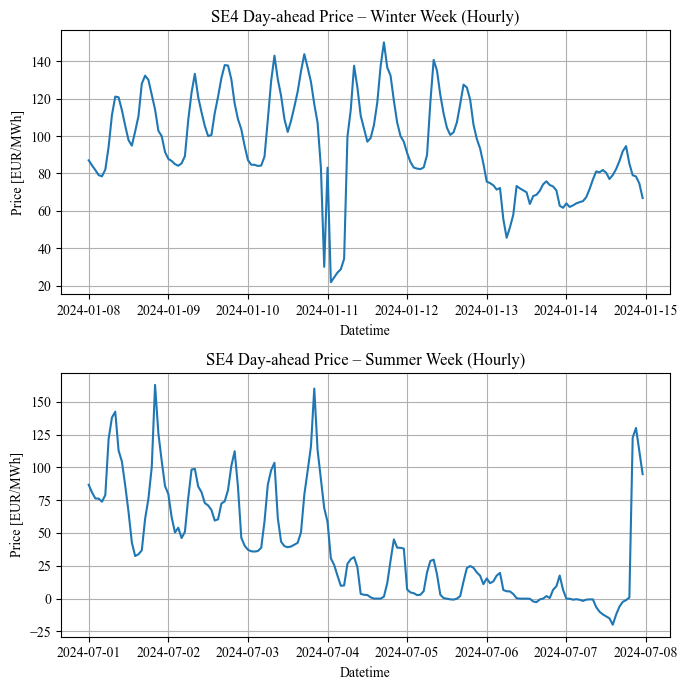

In [96]:
# Plot both weeks
plt.figure(figsize=(7,7))

plt.subplot(2,1,1)
plt.plot(winter_week.index, winter_week.values)
plt.title("SE4 Day-ahead Price – Winter Week (Hourly)")
plt.xlabel("Datetime")
plt.ylabel("Price [EUR/MWh]")
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(summer_week.index, summer_week.values)
plt.title("SE4 Day-ahead Price – Summer Week (Hourly)")
plt.xlabel("Datetime")
plt.ylabel("Price [EUR/MWh]")
plt.grid(True)

plt.tight_layout()
plt.show()

In [97]:
# let's also concatenate the two weeks into one Series. It is better for the next steps of the code
prices_w_s = pd.concat([winter_week, summer_week], ignore_index=True).rename("price")
prices_w_s.head(24)

0      87.02
1      84.32
2      81.82
3      79.11
4      78.48
5      82.10
6      94.30
7     111.22
8     121.11
9     120.73
10    113.90
11    105.54
12     97.84
13     94.88
14    102.46
15    110.64
16    128.00
17    132.31
18    130.01
19    122.12
20    114.21
21    102.83
22     99.98
23     91.49
Name: price, dtype: float64

### Developement of the optimization algorithm considering hourly electricity prices, vehicle departure schedules, battery charging requirements and network capacity constraints

#### Parameters and Interfaces

In [98]:
# List of depots (folders must exist: data/Output/<Depot>/...)
DEPOTS = ["ICA", "Mathem", "Postnord", "Airmee"]

def depot_base(depot):
    return os.path.join("data", "Output", depot)

# Output path for optimization results (per depot)
def fn_opt_output_depot(depot):
    return os.path.join(depot_base(depot), "optimization output", f"{depot}_charging_power_output.xlsx")

# Network limits (to be adjusted if necessary, but in this phase the task allowed us to have wider voltage variations)
VM_MIN, VM_MAX = 0.9, 1.1     # p.u.
LINE_MAX_LOADING = 100.0         # %
TRAF_MAX_LOADING  = 100.0        # %

The function below is used to to aggregate the charging power of the single EVs in the depots in load profiles per depot. There is a similar function already implemented in the code *calculate_charging_power* but we are creating this new one to prioritize clarity in this step

In [99]:
### Aggregates schedules into MW profiles per depot (for pandapower TS)

def schedule_to_profiles_charge(company_schedules: dict):

    profiles = []

    for company, P in company_schedules.items():
        # Sum all vehicle power (kW → MW)
        series_mw = P.sum(axis=1) / 1000.0
        series_mw.name = company
        profiles.append(series_mw)

    profiles_charge = pd.concat(profiles, axis=1).fillna(0.0)
    return profiles_charge


It's now useful to define a function that will calculate the total weekly costs for a company for charging all the EVs given the week prices and the schedule, since the costs reduction will be the objective of the optimization process. The total weekly charging cost is computed in EUR, and the arguments are given in kW (company schedule) and EUR/MWh (electricity prices). It will of course return the total weekly cost in EUR.

In [100]:

def weekly_cost_eur(company_schedules: dict, prices_week: pd.Series) -> float:

    # Sum total power across all companies (kW → MWh)
    total_kw = sum(P.sum(axis=1) for P in company_schedules.values())
    eur_per_kwh = prices_week / 1000.0  # EUR/MWh → EUR/kWh
    return float((total_kw * eur_per_kwh).sum())


#### Optimization  Process - iterative cycle


In [101]:
import pulp as pl

the function _find_sessions is used to find charging sessions, which means consecutive time steps in which the EV is available for charging. It returns the starting and the end of the charging session 

In [102]:

def _find_sessions(schedule01_np):

    s = schedule01_np.astype(int)
    T = len(s)
    sessions = []
    i = 0
    while i < T:
        if s[i] == 1:
            j = i + 1
            while j < T and s[j] == 1:
                j += 1
            sessions.append((i, j))
            i = j
        else:
            i += 1
    return sessions


The function loads the charging availability and energy consumption data for a given vehicle in a specific depot, reading the corresponding CSV files and returning both as numeric-indexed pandas Series. If the vehicle number doesn't return values, there are no more vehicles to be optimized in the depot

In [103]:
def prepare_vehicle_data(depot, vehicle_number):
    import os, pandas as pd

    base = os.path.join("data", "Output", depot)
    fn_chg = f"{depot}_all_vehicles_ChargingStation.csv"
    fn_cons = f"{depot}_all_vehicles_Consumption_kWh.csv"

    chg = pd.read_csv(os.path.join(base, fn_chg))
    cons = pd.read_csv(os.path.join(base, fn_cons))

    col_av  = f"ChargingStation_Vehicle_{vehicle_number}"
    col_cons = f"Consumption_kWh_Vehicle_{vehicle_number}"

    # Stop if the vehicle columns don't exist
    if col_av not in chg.columns or col_cons not in cons.columns:
        return "no more vehicles"

    availability = chg[col_av]
    consumption  = cons[col_cons]
    return availability, consumption


Parameters for optimization

In [104]:
# We do not care about battery capacity, as we know the consumption of the vehicle in the previous operational session we always charge it the amount of energy that it has consumed. This necessarily leads to the implicit check that we never charge more than the battery capacity.
C_Rating = 1 #The rate at which the battery charges.
# The capacity of a battery is commonly rated at 1C, meaning that a fully charged battery rated at 1Ah should provide 1A for one hour\n",
Ptrafo = 1200 #The capacity is in kW

CS_losses = 0.96 #charging losses efficiency factor

#charging_power = 22 #Rated EV charger in kW- each charge will be able to supply this capacity, already defined in previous steps

We need a helper function called assign session, to be coherent with what is done in the step4 tutorial while implementing our logic of optimizing per session. 

First we initialize the variables that are going to be used

In [105]:
Price = {}
Demand_hourly = {}
I = []
J = []

In [106]:
def assign_session(start, end, price_series, depot_demand):

    L = end - start
    I = list(range(L))  # local time indices (0, 1, ..., L-1)

    Price = {y: float(price_series.iloc[start + y]) for y in I}
    Demand_hourly = {y: float(depot_demand.iloc[start + y]) for y in I}


Now the optimization function. It is made to optimize each charging session individually for each vehicle

In [107]:
def Optimize(I,Price,E_sess,Charger_Power):

    # Define the optimization problem
    model = pl.LpProblem("Cost_minimize_charging_problem_session", pl.LpMinimize)

    # Decision variables: hourly charging power (kW)
    Charge_hourly = pl.LpVariable.dicts('Charge_hourly', I, lowBound=0, upBound=Charger_Power, cat='Continuous')

    # Constraint: total energy charged must equal required session energy, now considering the charging losses
    model += pl.lpSum(Charge_hourly[i] for i in I) == E_sess / CS_losses

    # Objective: minimize total charging cost
    model += pl.lpSum(Charge_hourly[i] * Price[i] for i in I)

    # Solve
    model.solve(pl.PULP_CBC_CMD(msg=False))

    # Extract results
    charge = [float(Charge_hourly[i].value() or 0.0) for i in I]
    cost = float(pl.value(model.objective)) if pl.value(model.objective) is not None else 0.0

    return charge, cost


Now we define a function that optimizes the overall charging session of a depot

In [108]:
def optimize_depot_charging_schedule(depot, prices, charger_power_kw):
    # Get the depot demand time series from df_depots - not used in current version, but already there to be used in step 5
    # depot_demand = df_depots[depot]

    price_MWh = prices
    T = len(prices)
    price_kWh = price_MWh / 1000.0
    # Output container: one column per vehicle, full week timeline
    P_opt = pd.DataFrame(index=range(T))  # numeric timesteps 0..T-1

    vehicle_number = 1
    while True:
        data = prepare_vehicle_data(depot, vehicle_number)
        if isinstance(data, str) and data == "no more vehicles":
            print(f"All vehicles processed for depot {depot}.")
            break

        availability, consumption = data
        availability = availability.iloc[:T]
        consumption = consumption.iloc[:T]

        # sessions for this vehicle (on availability 0/1)
        sessions = _find_sessions(availability.values)

        # per-vehicle charging power profile (kW)
        p_vehicle = np.zeros(T, dtype=float)

        # energy needed before each session = sum(consumption) since previous session end
        prev_end = 0
        for idx, (start, end) in enumerate(sessions):
            # energy needed for this session
            E_sess_local = float(consumption.iloc[prev_end:start].sum())
            prev_end = end  # update for next session

            I = list(range(end - start))
            prices_session = {i: float(price_kWh.iloc[start + i]) for i in I}

            charge_list, _ = Optimize(I=I, Price=prices_session, E_sess=float(E_sess_local), Charger_Power=float(charger_power_kw))

            # write session solution into vehicle profile
            p_vehicle[start:end] = np.array(charge_list, dtype=float)

        # add vehicle column to output
        P_opt[f"Vehicle_{vehicle_number}"] = p_vehicle

        print(f"Optimized vehicle {vehicle_number} in depot {depot}.")
        vehicle_number += 1

    # Save final CSV: data/Output/<depot>/<depot>_charging_power_optimized_by_price.csv
    out_dir = os.path.join("data", "Output", depot)
    os.makedirs(out_dir, exist_ok=True)
    out_csv = os.path.join(out_dir, f"{depot}_charging_power_optimized_by_price.csv")
    P_opt.to_csv(out_csv, index=False)

    print(f"\nSaved optimized charging power:\n  {out_csv}")
    return P_opt


We can now optimize all the depots!

In [109]:
# Run optimization depot by depot and keep results in a dict
all_results = {}

for depot in depots:
    print(f"\nOptimizing depot: {depot}")
    P_opt = optimize_depot_charging_schedule(depot, prices_w_s, charging_power)
    all_results[depot] = P_opt

print("\nAll depots optimized. CSV files saved under data/Output/<depot>/")



Optimizing depot: ICA
Optimized vehicle 1 in depot ICA.
Optimized vehicle 2 in depot ICA.
Optimized vehicle 3 in depot ICA.
Optimized vehicle 4 in depot ICA.
Optimized vehicle 5 in depot ICA.
Optimized vehicle 6 in depot ICA.
Optimized vehicle 7 in depot ICA.
Optimized vehicle 8 in depot ICA.
Optimized vehicle 9 in depot ICA.
All vehicles processed for depot ICA.

Saved optimized charging power:
  data/Output/ICA/ICA_charging_power_optimized_by_price.csv

Optimizing depot: Postnord
Optimized vehicle 1 in depot Postnord.
Optimized vehicle 2 in depot Postnord.
Optimized vehicle 3 in depot Postnord.
Optimized vehicle 4 in depot Postnord.
Optimized vehicle 5 in depot Postnord.
Optimized vehicle 6 in depot Postnord.
Optimized vehicle 7 in depot Postnord.
All vehicles processed for depot Postnord.

Saved optimized charging power:
  data/Output/Postnord/Postnord_charging_power_optimized_by_price.csv

Optimizing depot: Mathem
Optimized vehicle 1 in depot Mathem.
Optimized vehicle 2 in depot M

The code cell below simply takes the first 168 hours from winter_week (or the 336 hours of the combined winter and summer week, like is doing now), aligns both datasets (charging and profiles) to that same time window, and builds a final weekly dataframe that sums the charging load and profile values for each company in megawatts. 

In [110]:
# Use the first 336 timesteps (2 weeks)
L = 336
idx = range(L)

# Align to the target horizon (slice + reset_index for both sources)
combine = combine_hourly_sums_depots.iloc[:L].copy().reset_index(drop=True)

prof = profiles.copy()
if 'date' in prof.columns:
    prof = prof.set_index('date')
prof = prof.sort_index().iloc[:L].reset_index(drop=True)

# Build final DF in MW (charging totals are in kW -> /1000)
freight_load_and_charging = pd.DataFrame({'timestep': idx})
freight_load_and_charging['ICA']      = combine['Total_ICA'].to_numpy()      / 1000.0 + prof['ICA'].to_numpy()
freight_load_and_charging['Mathem']   = combine['Total_Mathem'].to_numpy()   / 1000.0 + prof['Mathem'].to_numpy()
freight_load_and_charging['Postnord'] = combine['Total_Postnord'].to_numpy() / 1000.0 + prof['Postnord'].to_numpy()
freight_load_and_charging['Airmee']   = combine['Total_Airmee'].to_numpy()   / 1000.0 + prof['Airmee'].to_numpy()

print(freight_load_and_charging.head(14))


    timestep       ICA    Mathem  Postnord    Airmee
0          0  0.853470  0.558823  0.476323  0.179549
1          1  0.862975  0.521902  0.473712  0.161848
2          2  0.839105  0.549134  0.450265  0.174293
3          3  0.817137  0.521987  0.458649  0.149116
4          4  0.838922  0.516426  0.418630  0.148731
5          5  1.219844  0.788451  1.045728  0.315488
6          6  1.358134  0.894910  1.240317  0.398194
7          7  1.366522  0.886890  1.260259  0.378633
8          8  1.408640  0.908408  1.279600  0.392371
9          9  1.376122  0.920890  1.272979  0.380523
10        10  1.398347  0.917718  1.290743  0.372157
11        11  1.276425  0.843779  1.096919  0.322828
12        12  1.256576  0.821649  1.087181  0.350920
13        13  1.281204  0.847164  1.111352  0.351447


Now we combine the depots profiles (there is a similar function already defined in the code, a further improvement could be eliminating this redoundancy)

In [111]:

base_output = os.path.join(notebook_dir, 'data', 'Output')
L = 336 # combined weeks
target_idx = prices_w_s.index[:L]

combined = pd.DataFrame({'date': target_idx})
for d in DEPOTS:
    f = os.path.join(base_output, d, f"{d}_charging_power_optimized_by_price.csv")
    df = pd.read_csv(f)
    s = df.iloc[:L, 1:].sum(axis=1) # sum vehicles (kW)
    combined[f"Total_{d}"] = s.values

out_path_v2 = os.path.join(base_output, "combine_hourly_sums_depots_v2.csv")
combined.to_csv(out_path_v2, index=False)
print(f"[v2] combine_hourly_sums_depots_v2 saved in {out_path_v2}")

combined.head(50)

[v2] combine_hourly_sums_depots_v2 saved in /Users/michelangeloinze/Desktop/Optmization of Energy Networks/Project/Group20_code/Step1_to_Step4/Step1_to_Step4/data/Output/combine_hourly_sums_depots_v2.csv


,date,Total_ICA,Total_Mathem,Total_Postnord,Total_Airmee
0,0,0.000000,0.000000,0.000000,0.000000
1,1,0.000000,0.000000,0.000000,0.000000
2,2,0.000000,0.000000,0.000000,0.000000
3,3,0.000000,0.000000,0.000000,0.000000
4,4,0.000000,0.000000,0.000000,0.000000
5,5,0.000000,0.000000,0.000000,0.000000
6,6,0.000000,0.000000,0.000000,0.000000
7,7,0.000000,0.000000,0.000000,0.000000
8,8,0.000000,0.000000,0.000000,0.000000
9,9,0.000000,0.000000,0.000000,0.000000


Now we align the profiles to the same week and build freight_load_and_charging_v2 (MW)

In [112]:
# Make profiles a 336h DatetimeIndex aligned to prices
p = profiles.copy()
if 'date' in p.columns:
    p['date'] = pd.to_datetime(p['date'])
    p = p.set_index('date')
p = p.sort_index().iloc[:L].copy()
p.index = target_idx

# Build final MW = depot kW / 1000 + baseline MW
freight_load_and_charging_v2 = pd.DataFrame({'date': target_idx})
freight_load_and_charging_v2['ICA']      = combined['Total_ICA'].values      / 1000.0 + p['ICA'].values
freight_load_and_charging_v2['Mathem']   = combined['Total_Mathem'].values   / 1000.0 + p['Mathem'].values
freight_load_and_charging_v2['Postnord'] = combined['Total_Postnord'].values / 1000.0 + p['Postnord'].values
freight_load_and_charging_v2['Airmee']   = combined['Total_Airmee'].values   / 1000.0 + p['Airmee'].values

out_path_v2 = os.path.join(base_output, "freight_load_and_charging_v2.xlsx")
freight_load_and_charging_v2.to_excel(out_path_v2, index=False)
print(f"[v2] freight_load_and_charging_v2 saved in {out_path_v2}")

freight_load_and_charging_v2.head()


[v2] freight_load_and_charging_v2 saved in /Users/michelangeloinze/Desktop/Optmization of Energy Networks/Project/Group20_code/Step1_to_Step4/Step1_to_Step4/data/Output/freight_load_and_charging_v2.xlsx


,date,ICA,Mathem,Postnord,Airmee
0,0,0.853470,0.558823,0.476323,0.179549
1,1,0.862975,0.521902,0.473712,0.161848
2,2,0.839105,0.549134,0.450265,0.174293
3,3,0.817137,0.521987,0.458649,0.149116
4,4,0.838922,0.516426,0.418630,0.148731


The cell below builds a new time-series network for pandapower, adds one load per depot, and links each load to its power profile (MW) over the two weeks using ConstControl.

In [113]:
# Build TS network and attach profiles from freight_load_and_charging_v2 
profiles_charge_v2 = freight_load_and_charging_v2[["ICA","Mathem","Postnord","Airmee"]].copy()

net_ts_charge_v2 = copy.deepcopy(net_base)

# One load per depot, init with first value
for depot, bus_id in depot_bus_map.items():
    pp.create_load(net_ts_charge_v2, bus=bus_id,
                   p_mw=profiles_charge_v2[depot].iat[0],
                   q_mvar=0, name=depot)

# Link time series
ds_v2 = DFData(profiles_charge_v2.reset_index(drop=True))
time_steps_v2 = ds_v2.df.index

# Clear existing controllers if any
if hasattr(net_ts_charge_v2, "controller") and len(net_ts_charge_v2.controller):
    net_ts_charge_v2.controller.drop(net_ts_charge_v2.controller.index, inplace=True)

for name in ["ICA","Mathem","Postnord","Airmee"]:
    load_idx = int(net_ts_charge_v2.load.index[net_ts_charge_v2.load.name == name][0])
    ConstControl(net_ts_charge_v2, element="load", variable="p_mw",
                 element_index=[load_idx], data_source=ds_v2, profile_name=[name])


Run timeseries and save results

In [114]:

out_dir_v2 = os.path.join(os.getcwd(), "results_charging_v2")
os.makedirs(out_dir_v2, exist_ok=True)

ow_v2 = OutputWriter(net_ts_charge_v2, time_steps=time_steps_v2,
                     output_path=out_dir_v2, output_file_type=".xlsx", log_variables=list())
ow_v2.log_variable('res_load', 'p_mw')
ow_v2.log_variable('res_bus', 'vm_pu')
ow_v2.log_variable('res_line', 'loading_percent')
ow_v2.log_variable('res_line', 'i_ka')
ow_v2.log_variable('res_trafo', 'loading_percent')

run_timeseries(net_ts_charge_v2, time_steps=time_steps_v2)
print(f"[v2] Results saved in: {out_dir_v2}")


100%|██████████| 336/336 [00:01<00:00, 298.44it/s]

[v2] Results saved in: /Users/michelangeloinze/Desktop/Optmization of Energy Networks/Project/Group20_code/Step1_to_Step4/Step1_to_Step4/results_charging_v2


Quick summary and plots

In [115]:
print("\nnet_ts_charge_v2 SUMMARY")
print(f"Total active power demand: {net_ts_charge_v2.load.p_mw.sum():.3f} MW")
print(f"Total reactive power demand: {net_ts_charge_v2.load.q_mvar.sum():.3f} Mvar")
print(f"Total number of loads: {len(net_ts_charge_v2.load)}")

res_bus_v2  = pd.read_excel(os.path.join(out_dir_v2, "res_bus",   "vm_pu.xlsx"), index_col=0)
res_line_v2 = pd.read_excel(os.path.join(out_dir_v2, "res_line",  "loading_percent.xlsx"), index_col=0)
res_trafo_v2= pd.read_excel(os.path.join(out_dir_v2, "res_trafo", "loading_percent.xlsx"), index_col=0)
res_load_v2 = pd.read_excel(os.path.join(out_dir_v2, "res_load",  "p_mw.xlsx"), index_col=0)



net_ts_charge_v2 SUMMARY
Total active power demand: 26.407 MW
Total reactive power demand: 5.520 Mvar
Total number of loads: 22


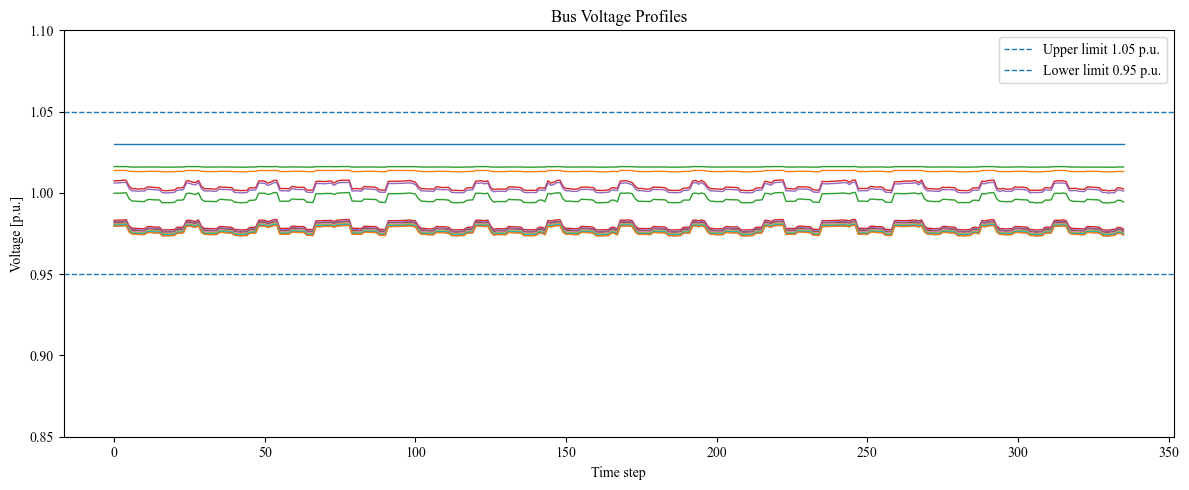

In [116]:
# Bus voltages with limits 0.95-1.05 p.u.
plt.figure(figsize=(12,5))
for col in res_bus_v2.columns:
    plt.plot(res_bus_v2[col], linewidth=1)
plt.axhline(1.05, linestyle='--', linewidth=1, label='Upper limit 1.05 p.u.')
plt.axhline(0.95, linestyle='--', linewidth=1, label='Lower limit 0.95 p.u.')
plt.title('Bus Voltage Profiles')
plt.xlabel('Time step'); plt.ylabel('Voltage [p.u.]')
plt.ylim(0.85, 1.10)
plt.legend(); plt.tight_layout(); plt.show()


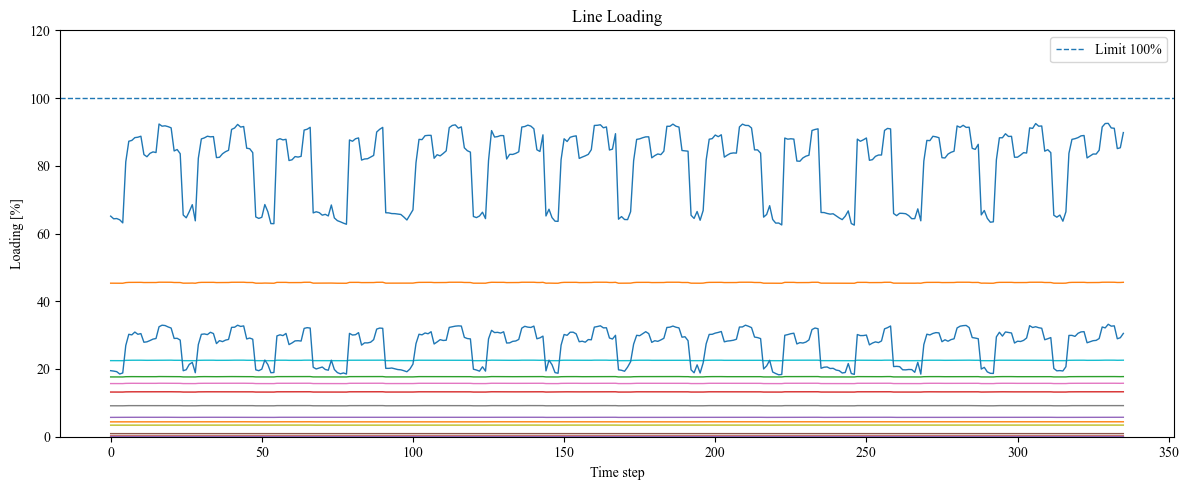

In [117]:
# Line loading with 100% thermal limit
plt.figure(figsize=(12,5))
for col in res_line_v2.columns:
    plt.plot(res_line_v2[col], linewidth=1)
plt.axhline(100, linestyle='--', linewidth=1, label='Limit 100%')
plt.title('Line Loading')
plt.xlabel('Time step'); plt.ylabel('Loading [%]')
plt.ylim(0, 120)
plt.legend(); plt.tight_layout(); plt.show()


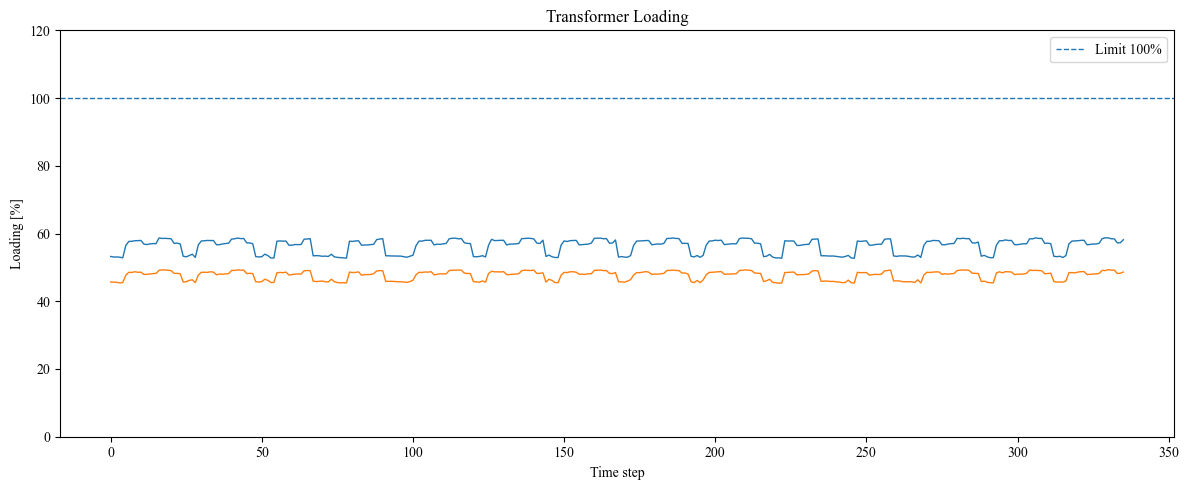

In [118]:
# Transformer loading with 100% thermal limit
plt.figure(figsize=(12,5))
for col in res_trafo_v2.columns:
    plt.plot(res_trafo_v2[col], linewidth=1)
plt.axhline(100, linestyle='--', linewidth=1, label='Limit 100%')
plt.title('Transformer Loading')
plt.xlabel('Time step'); plt.ylabel('Loading [%]')
plt.ylim(0, 120)
plt.legend(); plt.tight_layout(); plt.show()


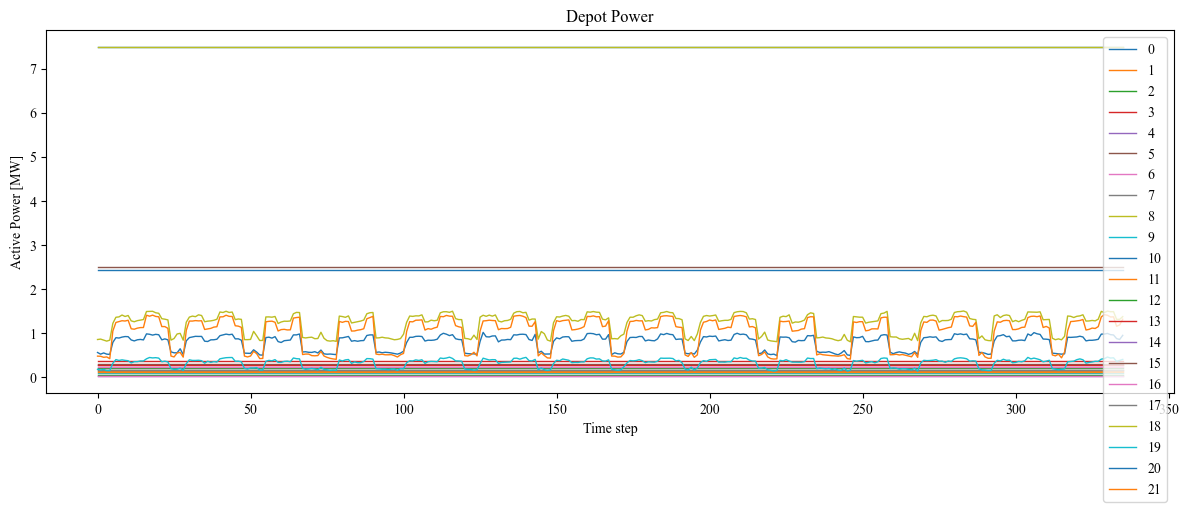

In [119]:
# Depot active power profiles (context, no explicit constraint)
plt.figure(figsize=(12,5))
for col in res_load_v2.columns:
    plt.plot(res_load_v2[col], linewidth=1, label=col)
plt.title('Depot Power')
plt.xlabel('Time step'); plt.ylabel('Active Power [MW]')
plt.legend(); plt.tight_layout(); plt.show()


### Economic + Network comparison, dumb charging vs optimized

In [120]:
# Paths
base_output_dir     = os.path.join(notebook_dir, 'data', 'Output')
results_baseline_dir = os.path.join(os.getcwd(), "results_charging")
results_opt_dir      = os.path.join(os.getcwd(), "results_charging_v2")

# Prices (EUR/MWh -> EUR/kWh) using all 336 timesteps from prices_w_s
_price_obj = globals()['prices_w_s']
price_week_kwh = ((_price_obj['price'] if isinstance(_price_obj, pd.DataFrame) else _price_obj).astype(float)) / 1000.0
target_idx = price_week_kwh.index
T = len(target_idx)  # should be 336

# Powers: read, sort, slice to T rows, then force index to target_idx
base = pd.read_excel(os.path.join(base_output_dir, "combine_hourly_sums_depots.xlsx")).copy()
opt  = pd.read_csv(os.path.join(base_output_dir, "combine_hourly_sums_depots_v2.csv")).copy()

base['date'] = pd.to_datetime(base['date']); base = base.sort_values('date').iloc[:T].copy(); base['date'] = target_idx
opt['date']  = pd.to_datetime(opt['date']);  opt  = opt.sort_values('date').iloc[:T].copy();  opt['date']  = target_idx

# Economic comparison (kW * EUR/kWh -> EUR)
def week_cost(df):
    return {d: float((df[f"Total_{d}"].to_numpy() * price_week_kwh.to_numpy()).sum()) for d in DEPOTS}

costs_base = pd.Series(week_cost(base), name='Baseline_EUR')
costs_opt  = pd.Series(week_cost(opt),  name='Optimized_EUR')
compare = pd.concat([costs_base, costs_opt], axis=1)
compare['Delta_EUR'] = compare['Optimized_EUR'] - compare['Baseline_EUR']
compare['Delta_%']   = compare['Delta_EUR'] / compare['Baseline_EUR'] * 100.0

print("\n=== ECONOMIC COMPARISON (EUR, two weeks (winter + summer) = {} steps) ===".format(T))
print(compare.round(2))




=== ECONOMIC COMPARISON (EUR, two weeks (winter + summer) = 336 steps) ===
          Baseline_EUR  Optimized_EUR  Delta_EUR  Delta_%
ICA             286.44         174.27    -112.17   -39.16
Mathem          152.10          77.78     -74.32   -48.86
Postnord        220.99         148.42     -72.57   -32.84
Airmee          145.10          56.77     -88.32   -60.87


Since in the optimized charging sessions we are not using exactly the same energy as in the 'dumb' charging (going to be shown in cell 122), a price comparison weighted on the energy used is more accurate and meaningful.

In [121]:
# AVERAGE EUR/MWh COMPARISON (Baseline vs Optimized) 

# Total weekly energy per depot (MWh), assuming 1-hour timesteps
energy_base = {d: float(base[f"Total_{d}"].sum()) / 1000.0 for d in DEPOTS}
energy_opt  = {d: float(opt[f"Total_{d}"].sum())  / 1000.0 for d in DEPOTS}

energy_base_s = pd.Series(energy_base, name="Baseline_MWh")
energy_opt_s  = pd.Series(energy_opt,  name="Optimized_MWh")

# Average price per MWh (EUR/MWh)
avg_base = (costs_base / energy_base_s).rename("Baseline_EUR_per_MWh")
avg_opt  = (costs_opt  / energy_opt_s ).rename("Optimized_EUR_per_MWh")

avg_compare = pd.concat([avg_base, avg_opt], axis=1)
avg_compare["Delta_EUR_per_MWh"] = avg_compare["Optimized_EUR_per_MWh"] - avg_compare["Baseline_EUR_per_MWh"]
avg_compare["Delta_%"] = (avg_compare["Delta_EUR_per_MWh"] / avg_compare["Baseline_EUR_per_MWh"]) * 100.0

# energy-weighted average
total_cost_base = float(costs_base.sum())
total_cost_opt  = float(costs_opt.sum())
total_energy_base = float(energy_base_s.sum())
total_energy_opt  = float(energy_opt_s.sum())

overall = pd.Series({
    "Baseline_EUR_per_MWh":  total_cost_base / total_energy_base,
    "Optimized_EUR_per_MWh": total_cost_opt  / total_energy_opt,
}, name="ALL")

overall["Delta_EUR_per_MWh"] = overall["Optimized_EUR_per_MWh"] - overall["Baseline_EUR_per_MWh"]
overall["Delta_%"] = (overall["Delta_EUR_per_MWh"] / overall["Baseline_EUR_per_MWh"]) * 100.0

avg_compare = pd.concat([avg_compare, overall.to_frame().T], axis=0)

print(f"\nAVERAGE EUR/MWh (using {T} hourly steps)")
print(avg_compare.round(2))



AVERAGE EUR/MWh (using 336 hourly steps)
          Baseline_EUR_per_MWh  Optimized_EUR_per_MWh  Delta_EUR_per_MWh  \
ICA                      69.36                  48.89             -20.47   
Mathem                   76.28                  49.71             -26.56   
Postnord                 65.71                  52.77             -12.94   
Airmee                   86.95                  53.89             -33.06   
ALL                      72.12                  50.83             -21.29   

          Delta_%  
ICA        -29.51  
Mathem     -34.83  
Postnord   -19.69  
Airmee     -38.02  
ALL        -29.52  


In [122]:
## Energy comparison
L = T  # same horizon (e.g. 336 hours)
tol = 1e-1

base_path = os.path.join(base_output_dir, "combine_hourly_sums_depots.xlsx")
opt_path  = os.path.join(base_output_dir, "combine_hourly_sums_depots_v2.csv")

base_df = pd.read_excel(base_path).iloc[:L].copy()
opt_df  = pd.read_csv(opt_path).iloc[:L].copy()

if 'date' in base_df.columns:
    base_df = base_df.sort_values('date').reset_index(drop=True)
if 'date' in opt_df.columns:
    opt_df = opt_df.sort_values('date').reset_index(drop=True)

# Check total energy per depot
rows = []
for d in DEPOTS:
    e_base = float(base_df[f"Total_{d}"].sum())
    e_opt  = float(opt_df[f"Total_{d}"].sum())
    rows.append({
        "Depot": d,
        "Base_kWh": e_base,
        "Optimized_kWh": e_opt,
        "Delta_kWh": e_opt - e_base,
    })

energy_check_total = pd.DataFrame(rows)
print("\n=== ENERGY COMPARISON PER DEPOT (kWh over {} steps) ===".format(L))
print(energy_check_total)





=== ENERGY COMPARISON PER DEPOT (kWh over 336 steps) ===
      Depot     Base_kWh  Optimized_kWh   Delta_kWh
0       ICA  4129.908132    3564.565312 -565.342820
1    Mathem  1994.062092    1564.661496 -429.400596
2  Postnord  3363.238007    2812.480707 -550.757300
3    Airmee  1668.743955    1053.544753 -615.199202


### Contingency Analys Step 4


In [123]:
hourly_results_Step4=cont_analysis_hourly(net_ts_charge_v2, 0.9, 1.1, 100, 100, load_profiles=profiles_charge_v2)
hourly_results_Step4

[0] Base max line load: Line 1-2 44.8%
[1] Base max line load: Line 1-2 44.1%
[2] Base max line load: Line 1-2 44.1%
[3] Base max line load: Line 1-2 43.6%
[4] Base max line load: Line 1-2 43.0%
[5] Base max line load: Line 1-2 59.5%
[6] Base max line load: Line 1-2 65.3%
[7] Base max line load: Line 1-2 65.4%
[8] Base max line load: Line 1-2 66.3%
[9] Base max line load: Line 1-2 66.1%
[10] Base max line load: Line 1-2 66.4%
[11] Base max line load: Line 1-2 61.4%
[12] Base max line load: Line 1-2 61.0%
[13] Base max line load: Line 1-2 61.9%
[14] Base max line load: Line 1-2 62.4%
[15] Base max line load: Line 1-2 62.3%
[16] Base max line load: Line 1-2 69.9%
[17] Base max line load: Line 1-2 69.6%
[18] Base max line load: Line 1-2 69.6%
[19] Base max line load: Line 1-2 69.3%
[20] Base max line load: Line 1-2 68.9%
[21] Base max line load: Line 1-2 62.7%
[22] Base max line load: Line 1-2 63.0%
[23] Base max line load: Line 1-2 61.9%
[24] Base max line load: Line 1-2 45.0%
[25] Base 

,hour,outaged_line_index,outaged_line_name,from_bus_voltage,to_bus_voltage,base_max_line_loading,base_max_line_name,base_margin_to_100,max_other_line_loading,max_other_line_name,postcont_margin_to_100,transformer_loading_max,critical_line
0,5,10,Line 12-13,1.017221,0.940055,59.483623,Line 1-2,40.516377,121.336113,Line 1-2,-21.336113,64.620293,True
1,6,0,Line 1-2,1.017380,0.912898,65.253066,Line 1-2,34.746934,101.166913,Line 12-13,-1.166913,67.983768,True
2,6,10,Line 12-13,1.017221,0.933816,65.253066,Line 1-2,34.746934,132.647738,Line 1-2,-32.647738,66.909210,True
3,7,0,Line 1-2,1.017380,0.912684,65.368731,Line 1-2,34.631269,101.203876,Line 12-13,-1.203876,67.994284,True
4,7,10,Line 12-13,1.017221,0.933999,65.368731,Line 1-2,34.631269,132.636906,Line 1-2,-32.636906,66.906577,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,332,10,Line 12-13,1.017221,0.929198,69.047851,Line 1-2,30.952149,140.476799,Line 1-2,-40.476799,68.495457,True
370,333,10,Line 12-13,1.017221,0.936255,63.144646,Line 1-2,36.855354,128.392236,Line 1-2,-28.392236,66.047635,True
371,334,10,Line 12-13,1.017221,0.935754,63.439643,Line 1-2,36.560357,129.111280,Line 1-2,-29.111280,66.193408,True
372,335,0,Line 1-2,1.017380,0.909468,67.253706,Line 1-2,32.746294,103.763741,Line 12-13,-3.763741,68.692863,True


In [124]:
count_table_4 = (hourly_results_Step4.groupby(['outaged_line_name', 'max_other_line_name']).size().reset_index(name='count'))
print(count_table_4)

  outaged_line_name max_other_line_name  count
0          Line 1-2          Line 12-13    131
1        Line 12-13            Line 1-2    243


## Post Processing

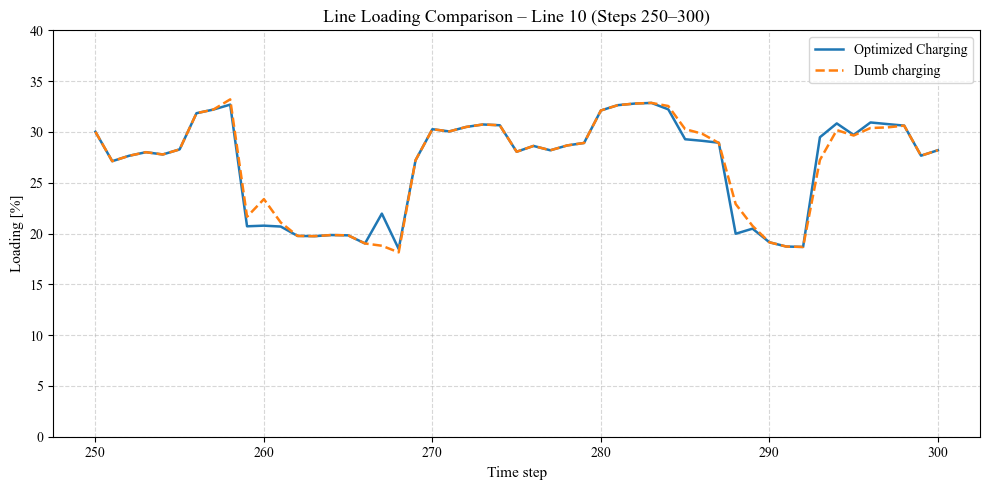

In [125]:
# Comparison line loading of line 10 between step 250 and 300

line_name = res_line_v2.columns[10]  
start, end = 250, 300

# extratct the range
opt_line = res_line_v2.loc[start:end, line_name]
dumb_line = res_line.loc[start:end, line_name]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(opt_line.index, opt_line.values, label='Optimized Charging', linewidth=1.8)
plt.plot(dumb_line.index, dumb_line.values, linestyle='--', label='Dumb charging', linewidth=1.8)

plt.title(f'Line Loading Comparison – Line 10 (Steps {start}–{end})', fontsize=13)
plt.xlabel('Time step', fontsize=11)
plt.ylabel('Loading [%]', fontsize=11)
plt.ylim(0, 40)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()



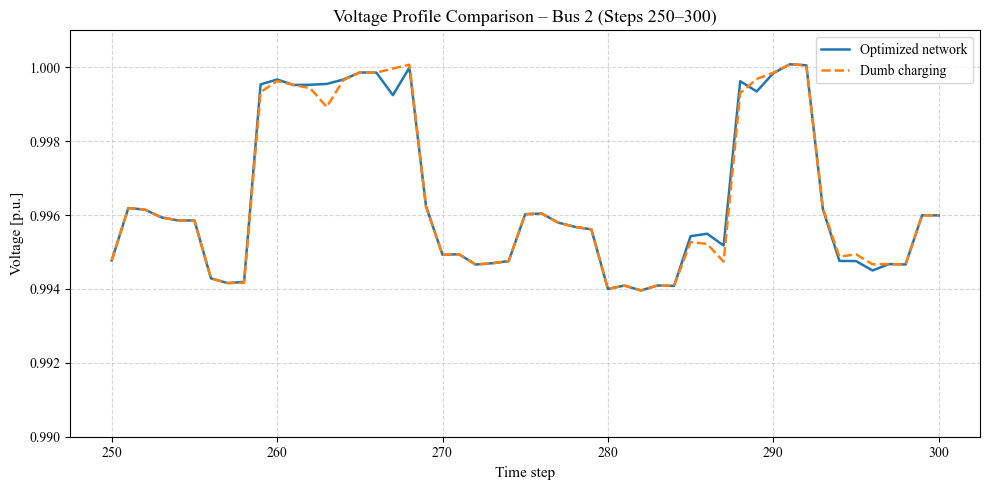

In [126]:
# Comparison of bus 2 voltage profile 2 between step 250 and 300

bus_name = res_bus_v2.columns[2] 
start, end = 250, 300

# Extract the range
opt_bus = res_bus_v2.loc[start:end, bus_name]
dumb_bus = res_bus.loc[start:end, bus_name]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(opt_bus.index, opt_bus.values, label='Optimized network', linewidth=1.8)
plt.plot(dumb_bus.index, dumb_bus.values, linestyle='--', label='Dumb charging', linewidth=1.8)

plt.title(f'Voltage Profile Comparison – Bus 2 (Steps {start}–{end})', fontsize=13)
plt.xlabel('Time step', fontsize=11)
plt.ylabel('Voltage [p.u.]', fontsize=11)
plt.ylim(0.99, 1.001)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


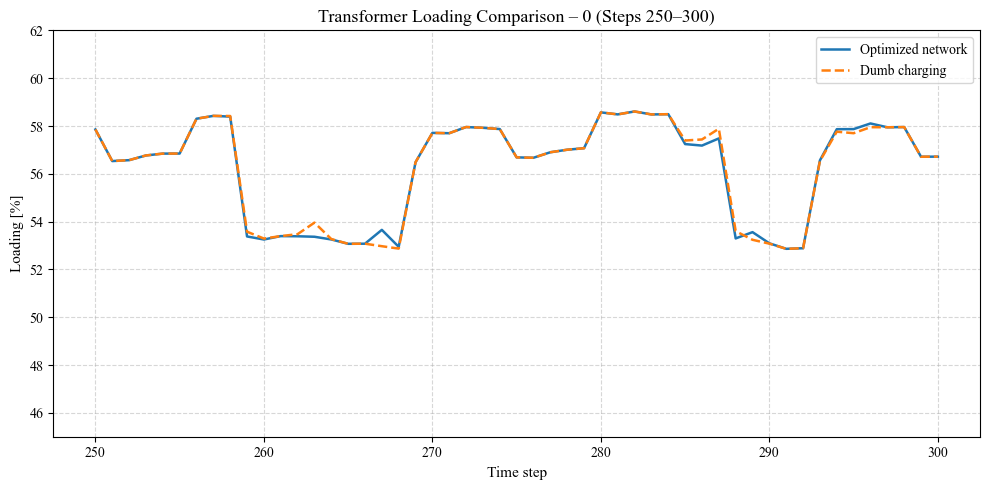

In [127]:
# Compare transformer loading  between steps 250–300

trafo_name = res_trafo_v2.columns[0]  
start, end = 250, 300

# Extract data for the range
opt_trafo = res_trafo_v2.loc[start:end, trafo_name]
dumb_trafo = res_trafo.loc[start:end, trafo_name]

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(opt_trafo.index, opt_trafo.values, label='Optimized network', linewidth=1.8)
plt.plot(dumb_trafo.index, dumb_trafo.values, linestyle='--', label='Dumb charging', linewidth=1.8)

plt.title(f'Transformer Loading Comparison – {trafo_name} (Steps {start}–{end})', fontsize=13)
plt.xlabel('Time step', fontsize=11)
plt.ylabel('Loading [%]', fontsize=11)
plt.ylim(45, 62)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
